# Differential GRNs

## Get differential accessibility for atlas peak matrix

In [2]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(org.Mm.eg.db))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [23]:
args = list()
args$sce = file.path(io$basedir, 'results/atac/archR/pseudobulk/celltype_genotype/PeakMatrix_atlas/PeakMatrix_atlas_pseudobulk_with_replicates.rds')
args$atac_matrix_file = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds')
args$groupA = 'WT'
args$groupB = 'Eomes_KO'
args$celltypes = opts$celltypes
args$outdir = file.path(io$basedir, 'results/atac/archR/differential')

args$archr_directory = file.path(io$basedir, 'processed/atac/archR')
args$metadata = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_after_qc.txt.gz')

In [26]:

dir.create(args$outdir, showWarnings = F)

# Define groups
opts$groups <- c(args$groupA,args$groupB)

opts$min_cdr <- 0.15

In [5]:
atac.mtx = readRDS(args$atac_matrix_file)

In [6]:
assayNames(atac.mtx)[1] <- "counts"

In [7]:
###############
## Load data ##
###############

print(sprintf("Fetching ATAC matrix: '%s'...",args$atac_matrix_file))

atac.se <- readRDS(args$sce)
assayNames(atac.se)[1] <- "counts"

# Normalise with log2 counts (for consistentcy with edgeR)
logcounts(atac.se) <- log2(1e6*(sweep(counts(atac.se),2,colSums(counts(atac.se)),"/"))+1)

# parse
if (!"celltype" %in% colnames(colData(atac.se))) {
  atac.se$celltype <- colnames(atac.se) %>% strsplit("-") %>% map_chr(1)
}
if (!"genotype" %in% colnames(colData(atac.se))) {
  atac.se$genotype <- colnames(atac.se) %>% strsplit("-") %>% map_chr(2) %>% strsplit("_rep") %>% map_chr(1)
}
if (!"celltype_genotype" %in% colnames(colData(atac.se))) {
  atac.se$celltype_genotype <- sprintf("%s_%s",atac.se$celltype,atac.se$genotype)
}

# temporary (otherwise subsetting doesn't work???)
if ("start" %in% colnames(rowData(atac.se))) {
  rowData(atac.se)$start <- NULL
}
if ("end" %in% colnames(rowData(atac.se))) {
  rowData(atac.se)$end <- NULL
}

[1] "Fetching ATAC matrix: '/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/processed/atac/archR/Matrices/PeakMatrix_atlas_summarized_experiment.rds'..."


In [8]:
atac.se_full = atac.se

In [9]:
suppressPackageStartupMessages(library(ArchR))
setwd(args$archr_directory)

addArchRVerbose(verbose = FALSE)
addArchRGenome("mm10")

Setting addArchRVerbose = FALSE

Setting default genome to Mm10.



In [10]:
########################
## Load cell metadata ##
########################

cell_metadata.dt <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE]

## Load ArchRProject
# Subset
ArchRProject <- loadArchRProject(args$archr_directory)[cell_metadata.dt$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [11]:
meta = as.data.table(ArchRProject@cellColData)

features = rownames(atac.mtx)

In [12]:
keep = rownames(ArchRProject@cellColData)

In [13]:
atac.mtx = atac.mtx[,keep]

In [14]:
table(ArchRProject@cellColData$celltype, ArchRProject@cellColData$genotype)

                                
                                 Eomes_KO    WT
  Anterior_Primitive_Streak           151  1892
  Blood_progenitors_1                   0     1
  Caudal_epiblast                     151    95
  Caudal_Mesoderm                      88    20
  Caudal_neurectoderm                   3     3
  Def._endoderm                        16  1335
  Endothelium                           2     0
  Epiblast                           2242  8096
  ExE_ectoderm                          1     0
  Forebrain_Midbrain_Hindbrain         72   186
  Gut                                   0   116
  Haematoendothelial_progenitors       13     2
  Intermediate_mesoderm               259    54
  Mixed_mesoderm                       28     7
  Nascent_mesoderm                    510   710
  Neural_crest                          3     0
  NMP                                 294    37
  Notochord                             0   300
  Paraxial_mesoderm                  1359   170
  Parie

In [15]:
getAvailableMatrices(ArchRProject)

[1] "DeviationMatrix_CISBP"  "DeviationMatrix_JASPAR" "GeneScoreMatrix_TSS"   
[4] "GeneScoreMatrix_distal" "PeakMatrix"             "PeakMatrix_atlas"      
[7] "TileMatrix"

In [16]:
atac.mtx

class: RangedSummarizedExperiment 
dim: 192251 46547 
metadata(0):
assays(1): counts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(46547): RBG43471#AAACAGCCAACACTTG-1
  RBG43471#AAACAGCCACATACTG-1 ... RBG43478#TTTGTTGGTGCATTAG-1
  RBG43478#TTTGTTGGTTAGGTTG-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [17]:
test = getMatrixFromProject(ArchRProject, "PeakMatrix_atlas")

In [18]:
test

class: RangedSummarizedExperiment 
dim: 192251 46547 
metadata(0):
assays(1): PeakMatrix_atlas
rownames: NULL
rowData names(1): idx
colnames(46547): RBG43473#CCAGGATGTCAGGCAT-1
  RBG43473#AAACATGCATCAGCAC-1 ... RBG43478#AAGCTAGAGGAACCAA-1
  RBG43478#GTGCTGATCTGTTCAT-1
colData names(38): BlacklistRatio nDiFrags ... ReadsInPeaks FRIP

In [27]:
DARs = lapply(unique(ArchRProject@cellColData$celltype), function(ct, min_cells=25){ #args$celltypes
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (nrow(meta[celltype_genotype == paste0(ct, '-Eomes_KO')]) < min_cells | nrow(meta[celltype_genotype == paste0(ct, '-WT')]) < min_cells) {
      out <- data.table(Log2FC=NA, Mean=NA, FDR=NA, Pval=NA, MeanDiff=NA, MeanBGD=NA, idx=NA, feature=NA)
      message('skipping ', ct, ' due to low cell number')
    } else {
        
        #stopifnot(opts$groups%in%atac.se$genotype)
        #atac.se$genotype <- factor(atac.se$genotype, levels=opts$groups)
        
        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate

        atac.mtx_tmp <- atac.mtx[,atac.mtx$celltype %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2)
        )
        
        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]
        message(ct, ' with ', length(features.to.use), ' regions')

        #ArchRProject.filt = ArchRProject[ArchRProject@cellColData$celltype==ct,]
        ##########################
        ## Differential testing ##
        ##########################
        
        # sometimes get errors, because of NA's in matrix? but ArchR doesn't allow me to subset the peakmatrix
        out <- suppressMessages(getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix_atlas",
          groupBy = "celltype_genotype",
          testMethod = "binomial",
          binarize=TRUE,
          useGroups = paste0(ct, '-Eomes_KO'),
          bgdGroups = paste0(ct, '-WT'),
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        ))
        
        # ArchR doesn't allow to select only specified features for differential testing, so instead I run it on everything 
        # Here I select only the relevant features and redo fdr correction.
        out = as.data.table(do.call("cbind", out@assays@data)) %>% 
            setnames(names(out@assays@data)) %>%
            .[,idx:=1:nrow(.)] %>%
            .[,feature := features] %>% 
            .[feature %in% features.to.use,] %>%
            .[,FDR := p.adjust(Pval, method = 'fdr')]
        
        
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}) %>%  rbindlist(.) %>% 
    setnames(c('Log2FC', 'FDR'), c('logFC', 'padj_fdr'))

Epiblast with 24396 regions

Rostral_neurectoderm with 18754 regions

Primitive_Streak with 26386 regions

PGC with 21499 regions

skipping Def._endoderm due to low cell number

Forebrain_Midbrain_Hindbrain with 18484 regions

NMP with 21733 regions

Nascent_mesoderm with 24480 regions

skipping Parietal_endoderm due to low cell number

Caudal_epiblast with 18986 regions

Anterior_Primitive_Streak with 28927 regions

Surface_ectoderm with 16138 regions

skipping ExE_ectoderm due to low cell number

skipping Visceral_endoderm due to low cell number

Somitic_mesoderm with 22539 regions

Paraxial_mesoderm with 21954 regions

skipping Caudal_neurectoderm due to low cell number

Intermediate_mesoderm with 18961 regions

skipping Caudal_Mesoderm due to low cell number

Spinal_cord with 21709 regions

skipping Mixed_mesoderm due to low cell number

skipping Pharyngeal_mesoderm due to low cell number

skipping Haematoendothelial_progenitors due to low cell number

skipping Neural_crest due to 

In [28]:
fwrite(DARs, file.path(args$outdir, 'DARs_PeakMatrix_atlas.txt.gz'))

## Load eGRN

In [20]:
suppressMessages(library(igraph))
suppressMessages(library(GGally))
suppressMessages(library(igraph))
suppressMessages(library(network))
suppressMessages(library(ggraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))

Warning message:
“package ‘network’ was built under R version 4.1.3”
Warning message:
“package ‘tidygraph’ was built under R version 4.1.3”


In [29]:
scenic_eGRN = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/scenicplus/endoderm/scenicplus/eRegulon_metadata_filtered.csv')
DARs = fread(file.path(args$outdir, 'DARs_PeakMatrix_atlas.txt.gz')) %>%
    .[,sig:=ifelse(padj_fdr<0.05 & abs(logFC) > 0.5, TRUE, FALSE)]
DEGs = fread(file.path(io$basedir, '/results/rna/differential/DEGs.txt.gz')) %>%
    .[,sig:=ifelse(padj_fdr<0.05 & abs(logFC) > 1, TRUE, FALSE)]

In [30]:
scenic_eGRN_small = scenic_eGRN[,c('TF', 'Region', 'Gene', 'TF2G_rho')] %>% .[Gene %in% TF]

In [31]:
plotDGRN = function(celltype_i){
    DARs_tmp = DARs[celltype == celltype_i, c('feature', 'logFC', 'sig')]
    DEGs_tmp = DEGs[celltype == celltype_i, c('gene', 'logFC', 'sig')]
    scenic_eGRN_tmp = scenic_eGRN[TF %in% DEGs_tmp[sig==TRUE, gene] & Region %in% DARs_tmp[sig==TRUE, feature]] %>%
        .[TF %in% .[,.N,by="TF"][N>=3,TF]] # keep only TFs with 3 or more targets differential
    
    TF_region = scenic_eGRN_tmp[,c('TF', 'Region', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    region_gene = scenic_eGRN_tmp[,c('Region', 'Gene', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    edges = rbind(TF_region, region_gene)
    
    DAR_DEGs = rbind(DARs_tmp, DEGs_tmp, use.names=FALSE) %>% setnames('feature', 'node')
    
    edges_tmp = edges[node %in% c(DARs_tmp$feature, DEGs_tmp$gene)] %>%
    unique(by=c('node', 'target'))
    
    
    nodes_tmp = data.table(node = unique(c(edges_tmp$node, edges_tmp$target))) %>%
    .[,type:=ifelse(node %in% scenic_eGRN$TF, 'TF', ifelse(node %in% scenic_eGRN$Region, 'Region', 'gene'))] %>%
    merge(.,DAR_DEGs, by='node', all.x=TRUE) %>%
    .[,logFC:=ifelse(is.na(logFC), 0, logFC)]
    
    igraph.tbl = tbl_graph(edges = edges_tmp, nodes = nodes_tmp)
    
    options(repr.plot.width=20, repr.plot.height=10)

    ggraph(igraph.tbl, 'stress') +
    # Edges
        geom_edge_fan(edge_color = 'darkgreen', edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(3,'mm'), show.legend = T) + 
    # nodes
        geom_node_point(aes(color=logFC, size=ifelse(type=='TF', 10, ifelse(type=='Region', 3, 5)))) + 
        scale_colour_gradient2(low='blue', mid='gray', high='red') +
        geom_node_text(aes(filter=type!='Region', label=node)) +
    ggtitle(celltype_i) + 
    theme_graph() + 
    theme(legend.position='none',
        text=element_text(size=20)) 
        
}

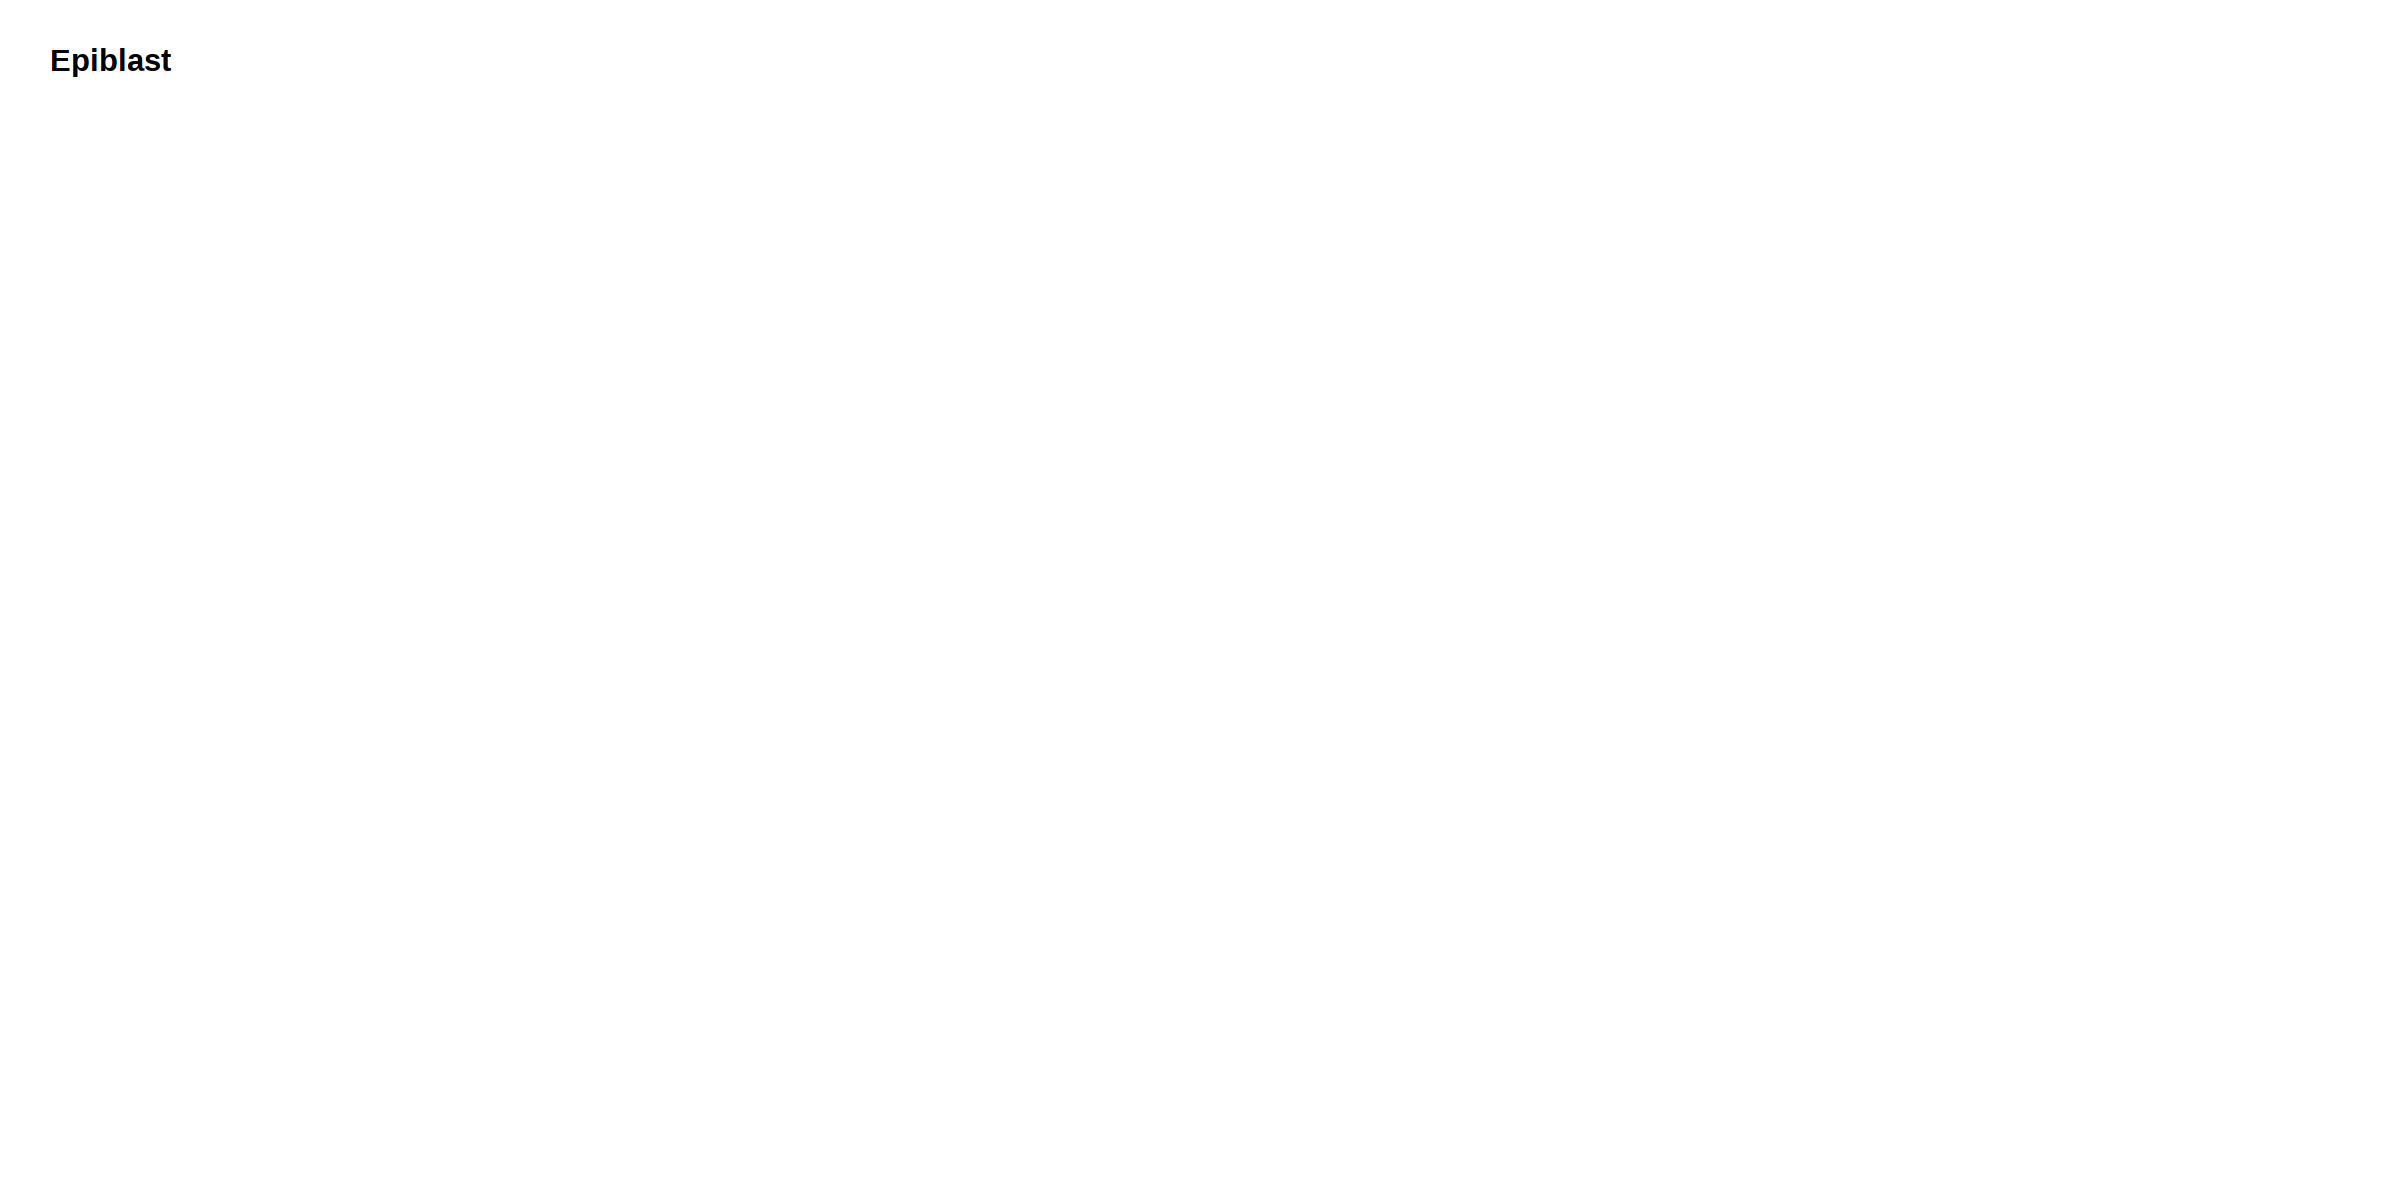

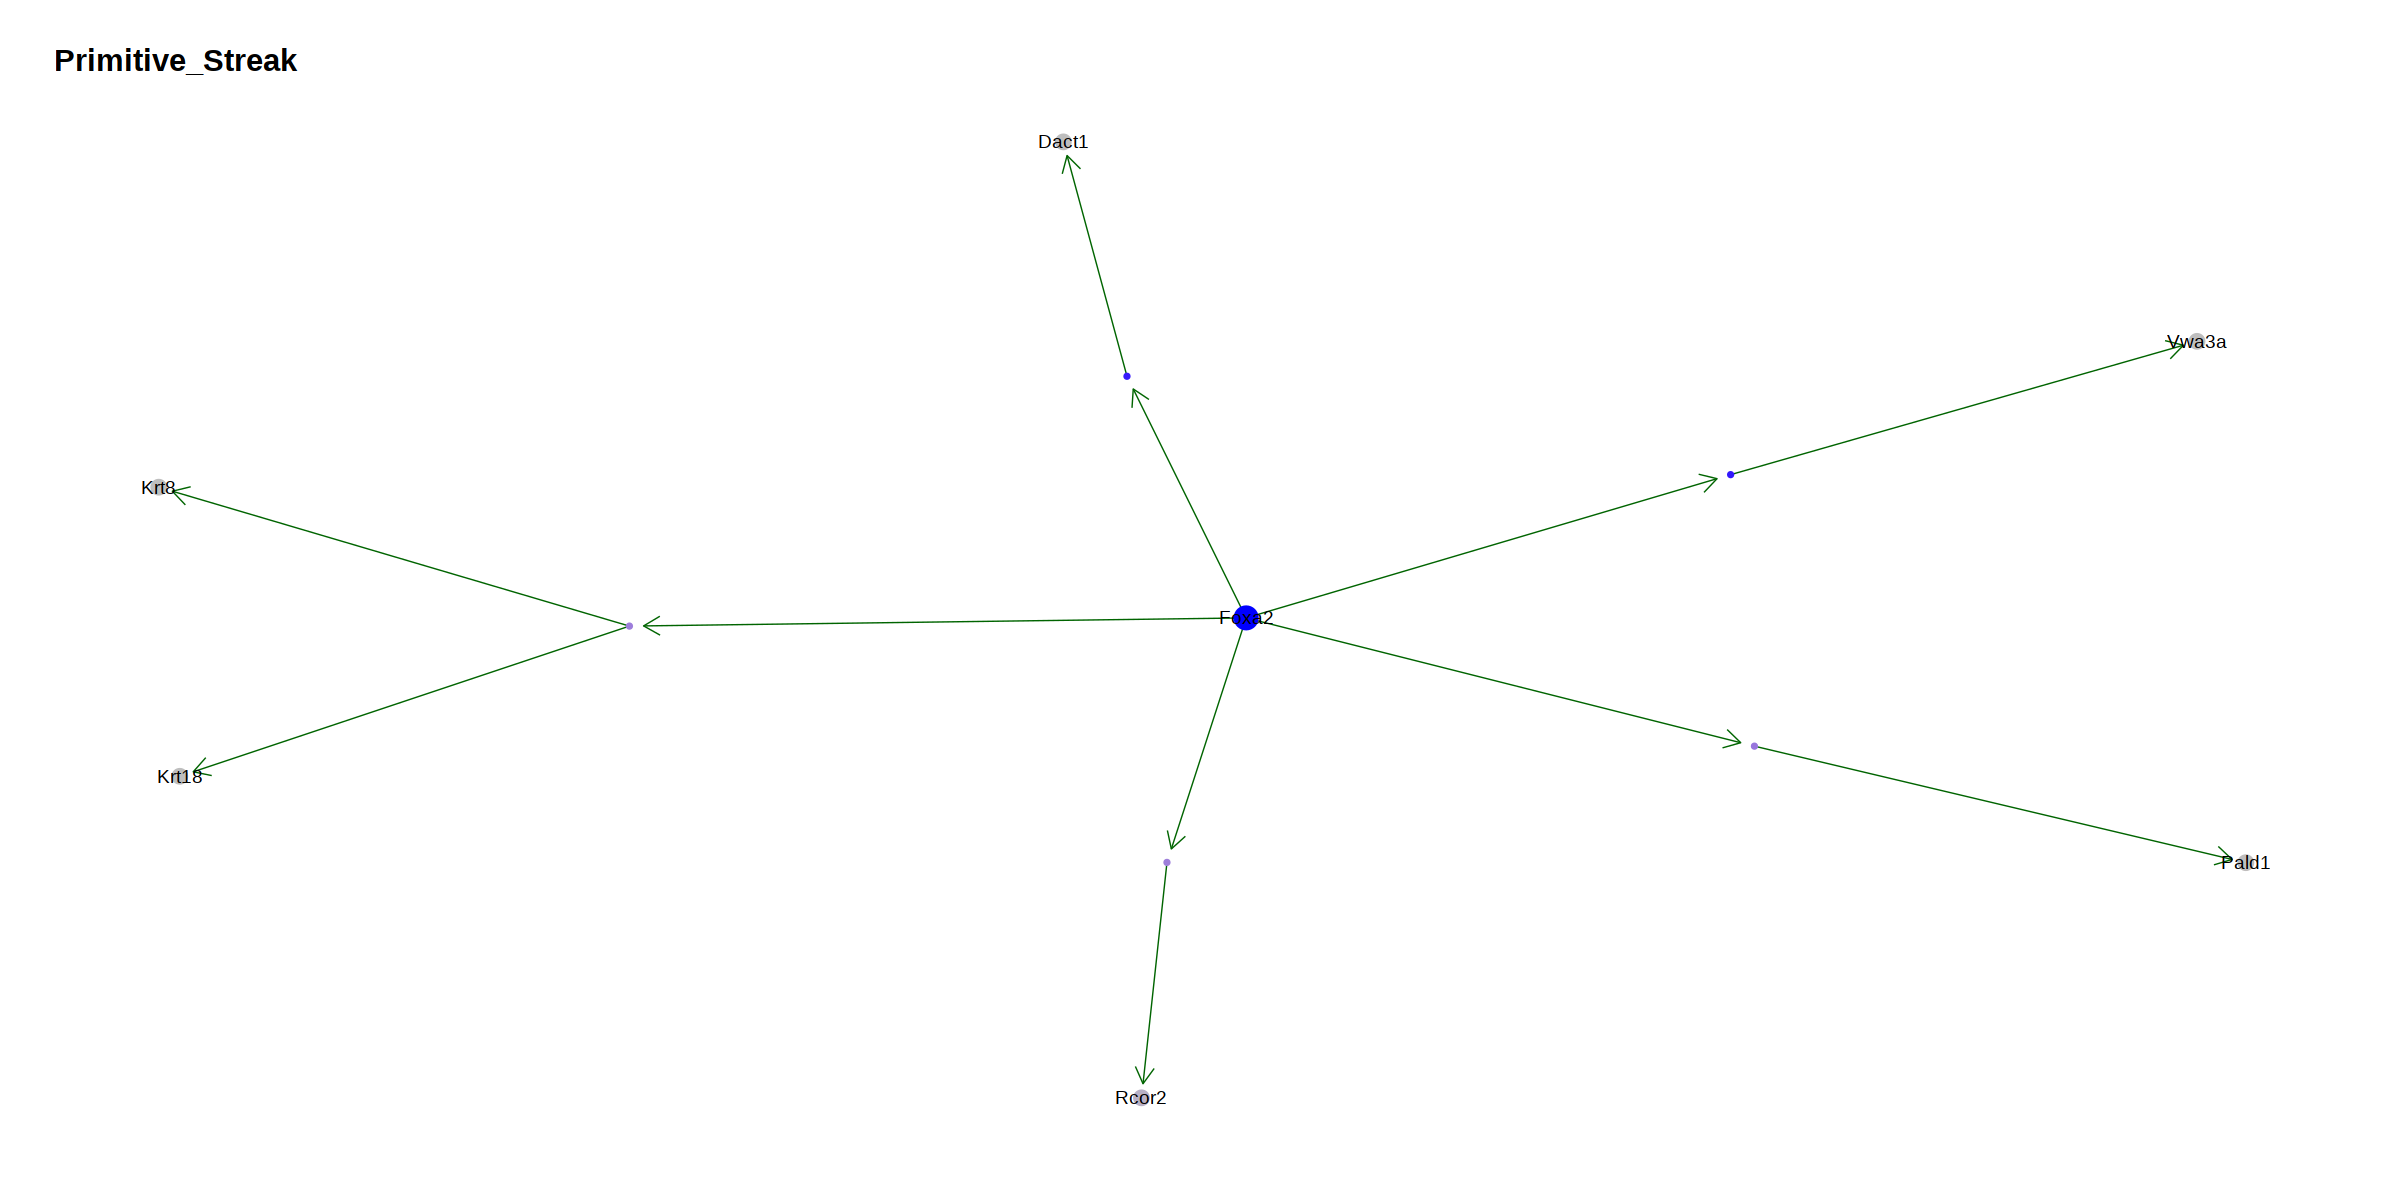

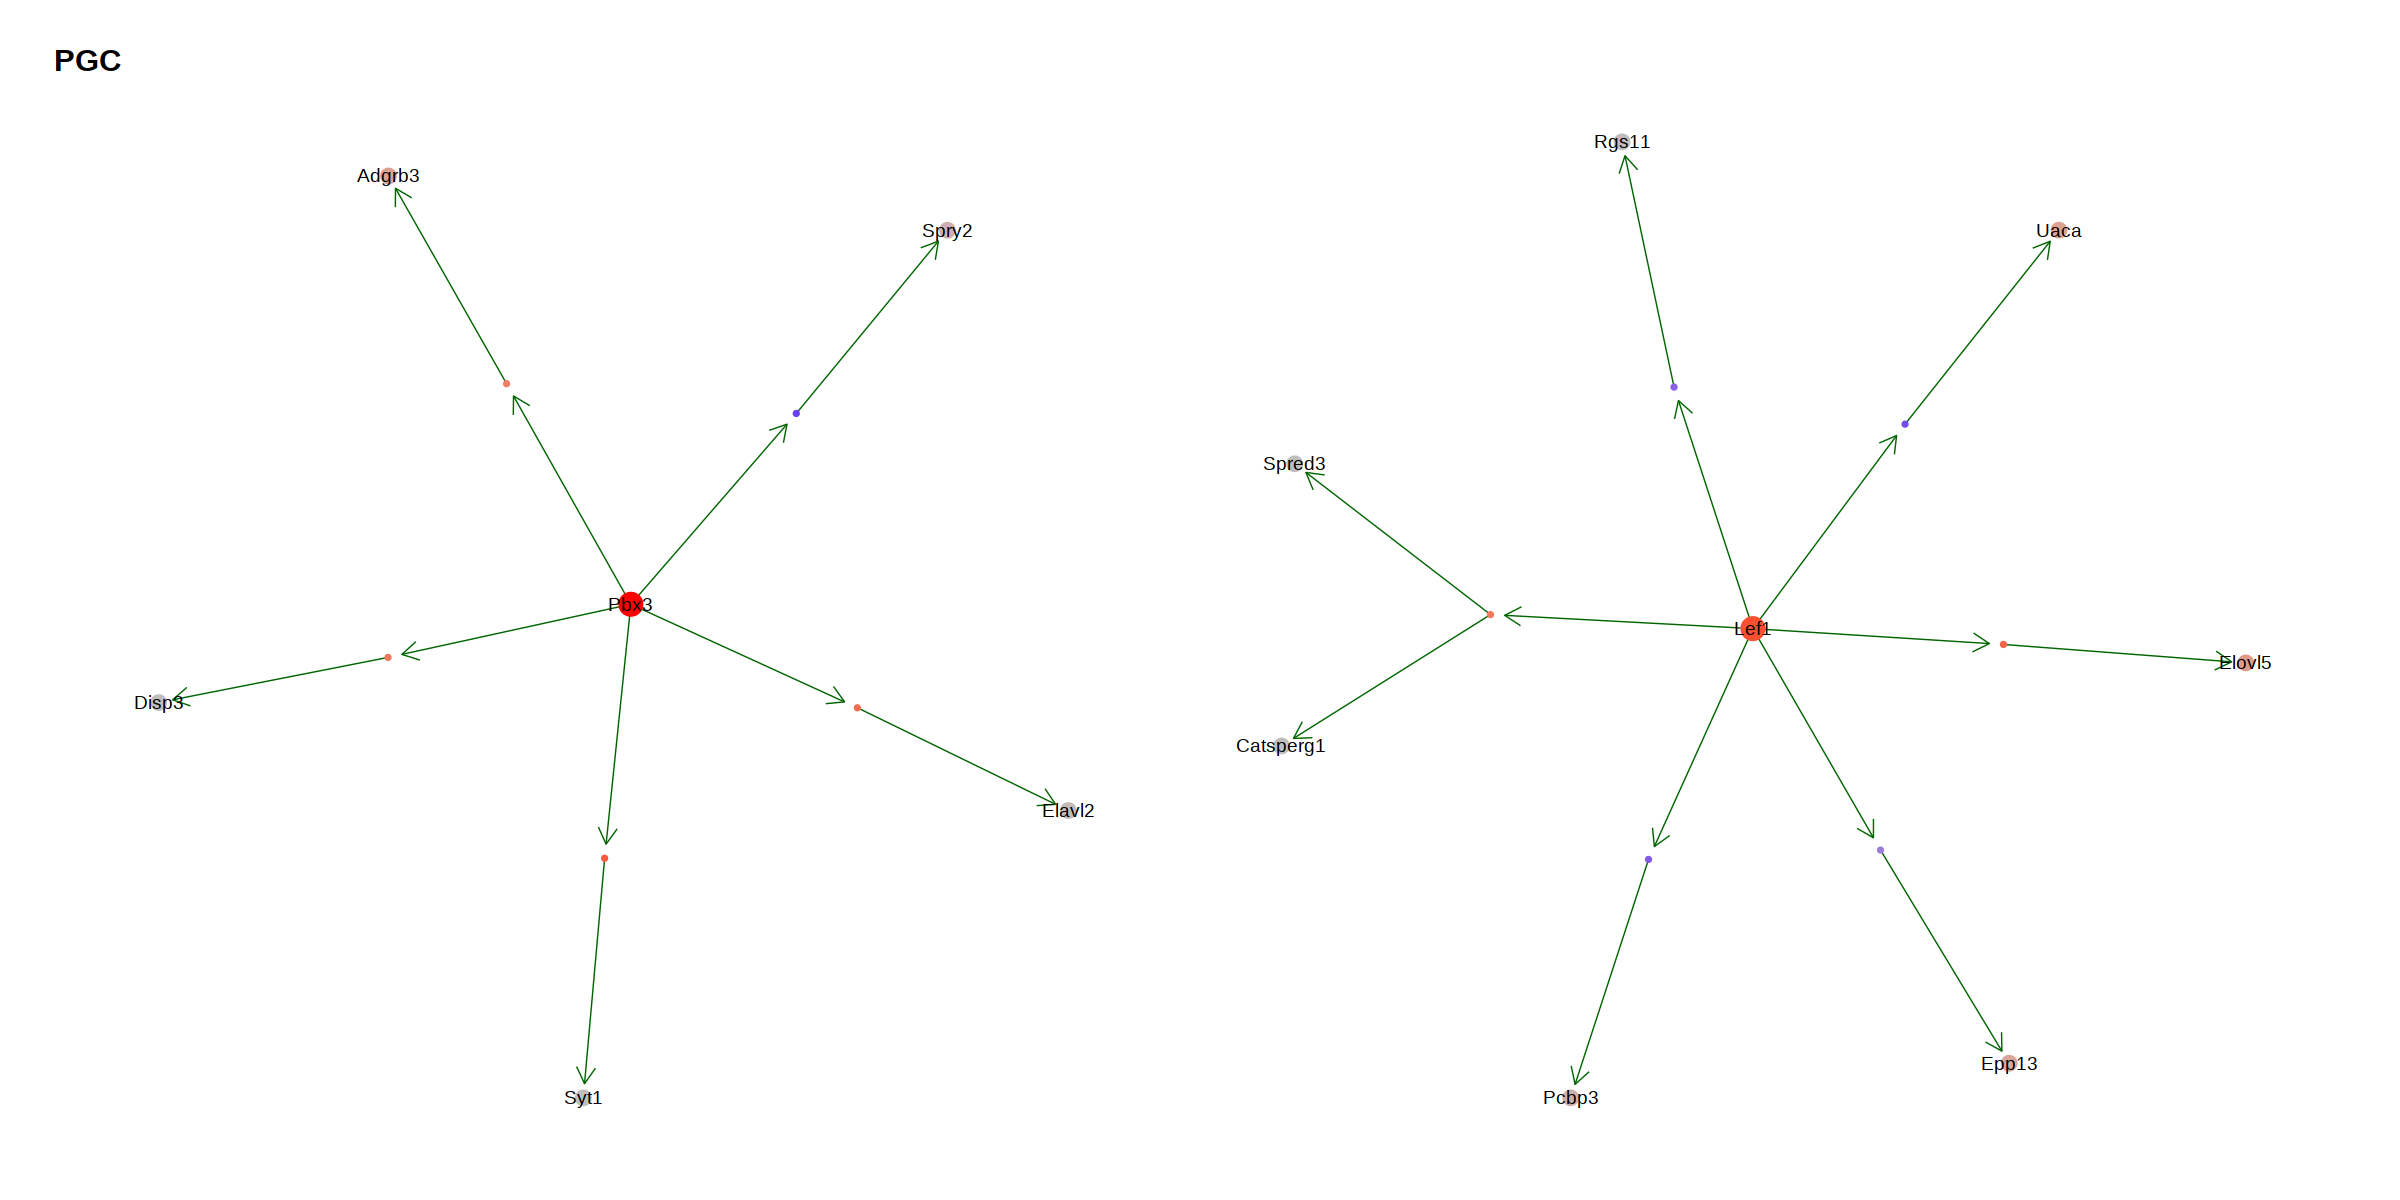

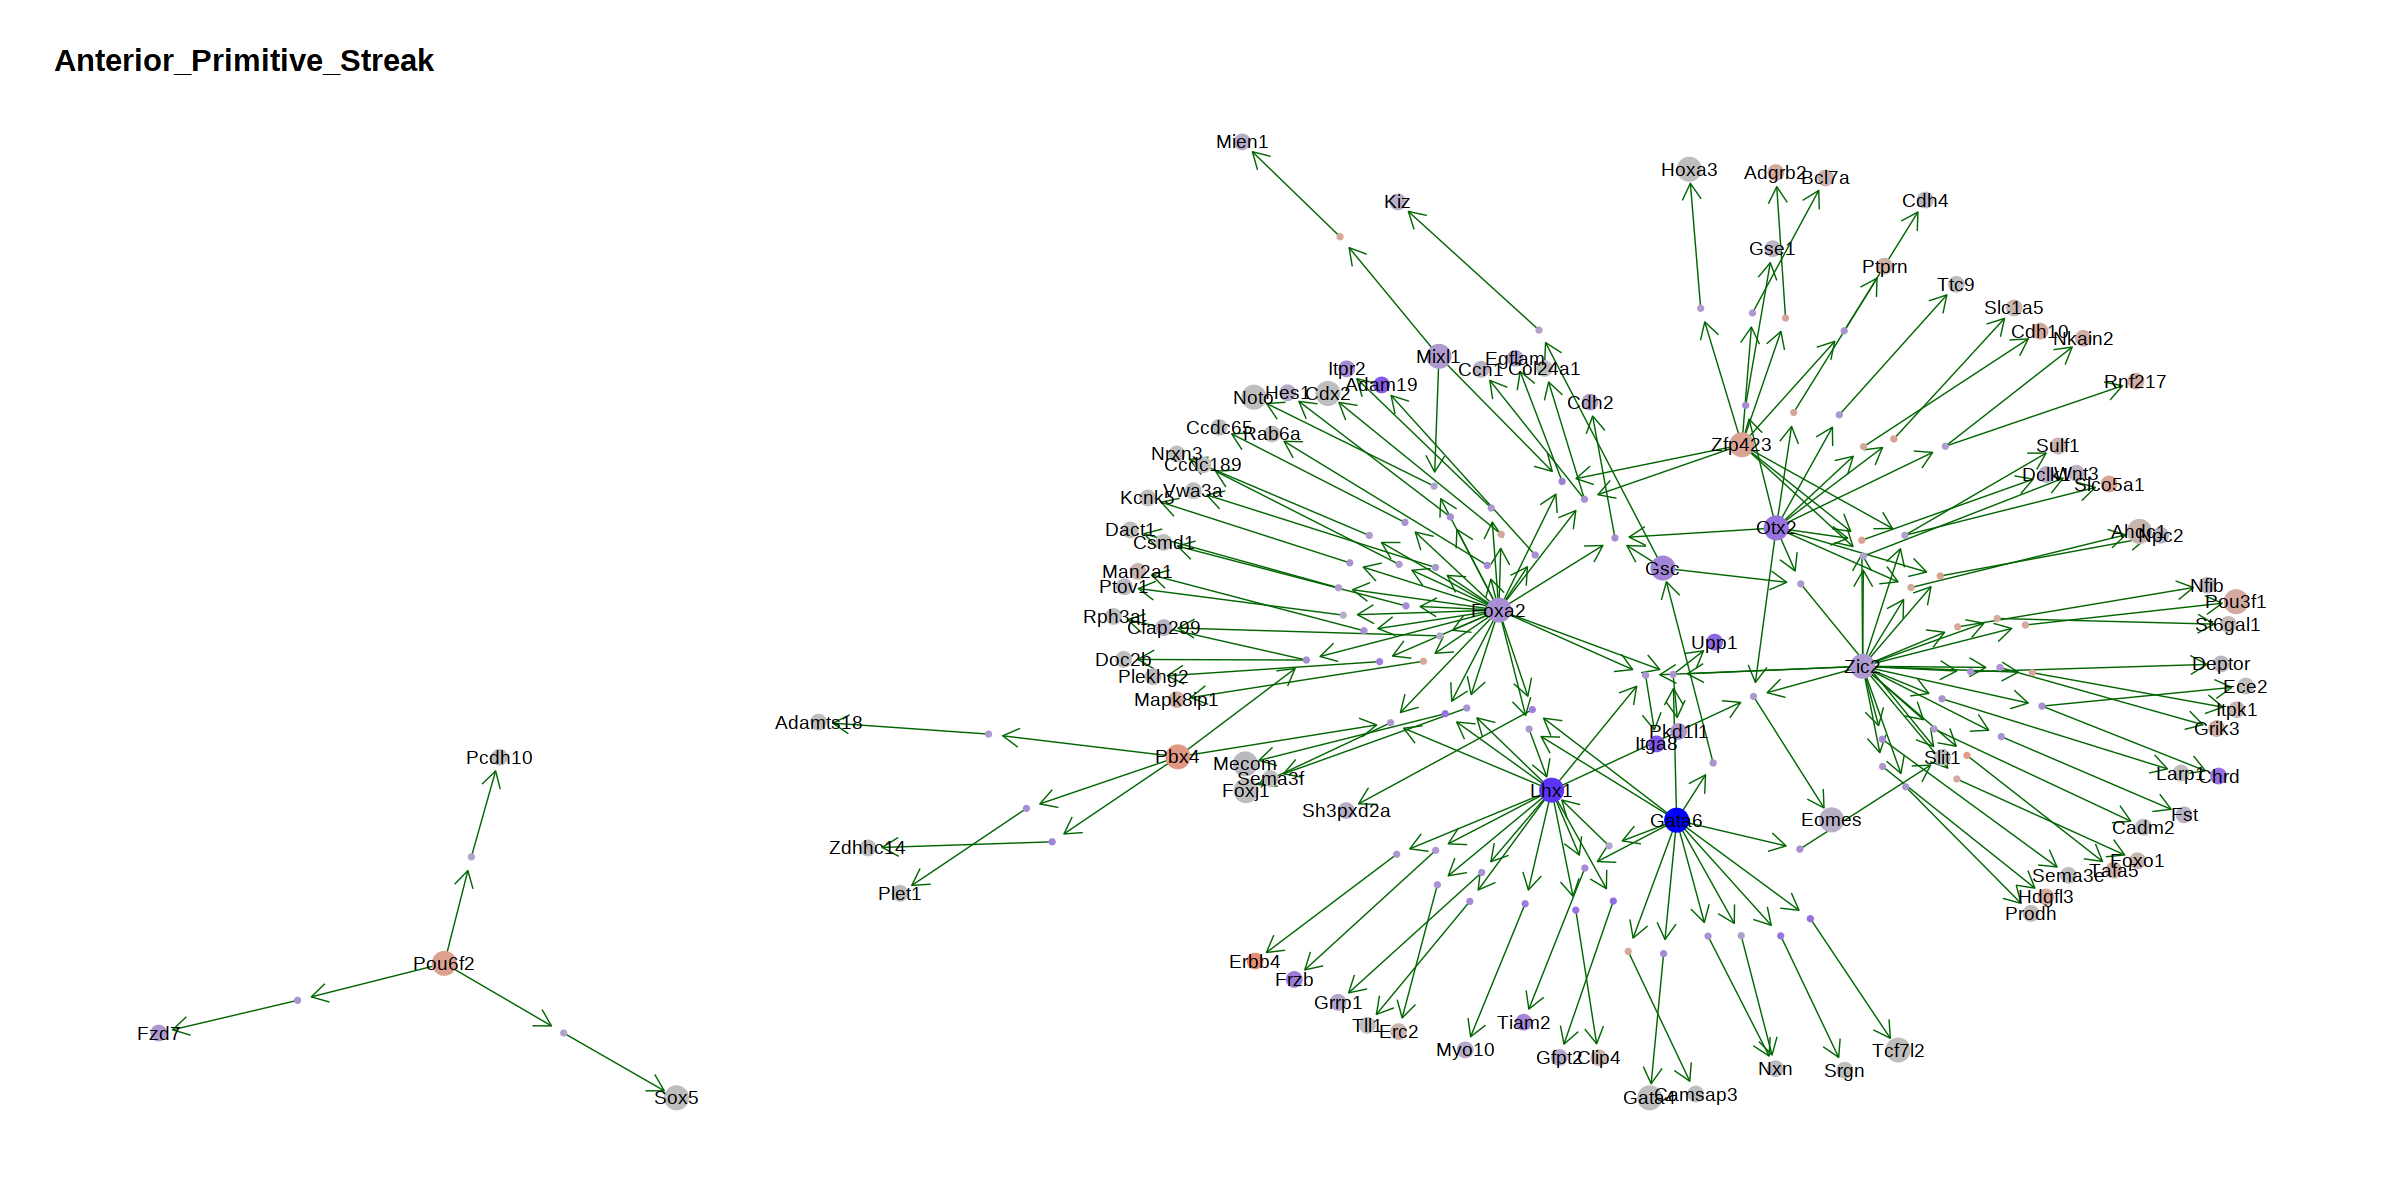

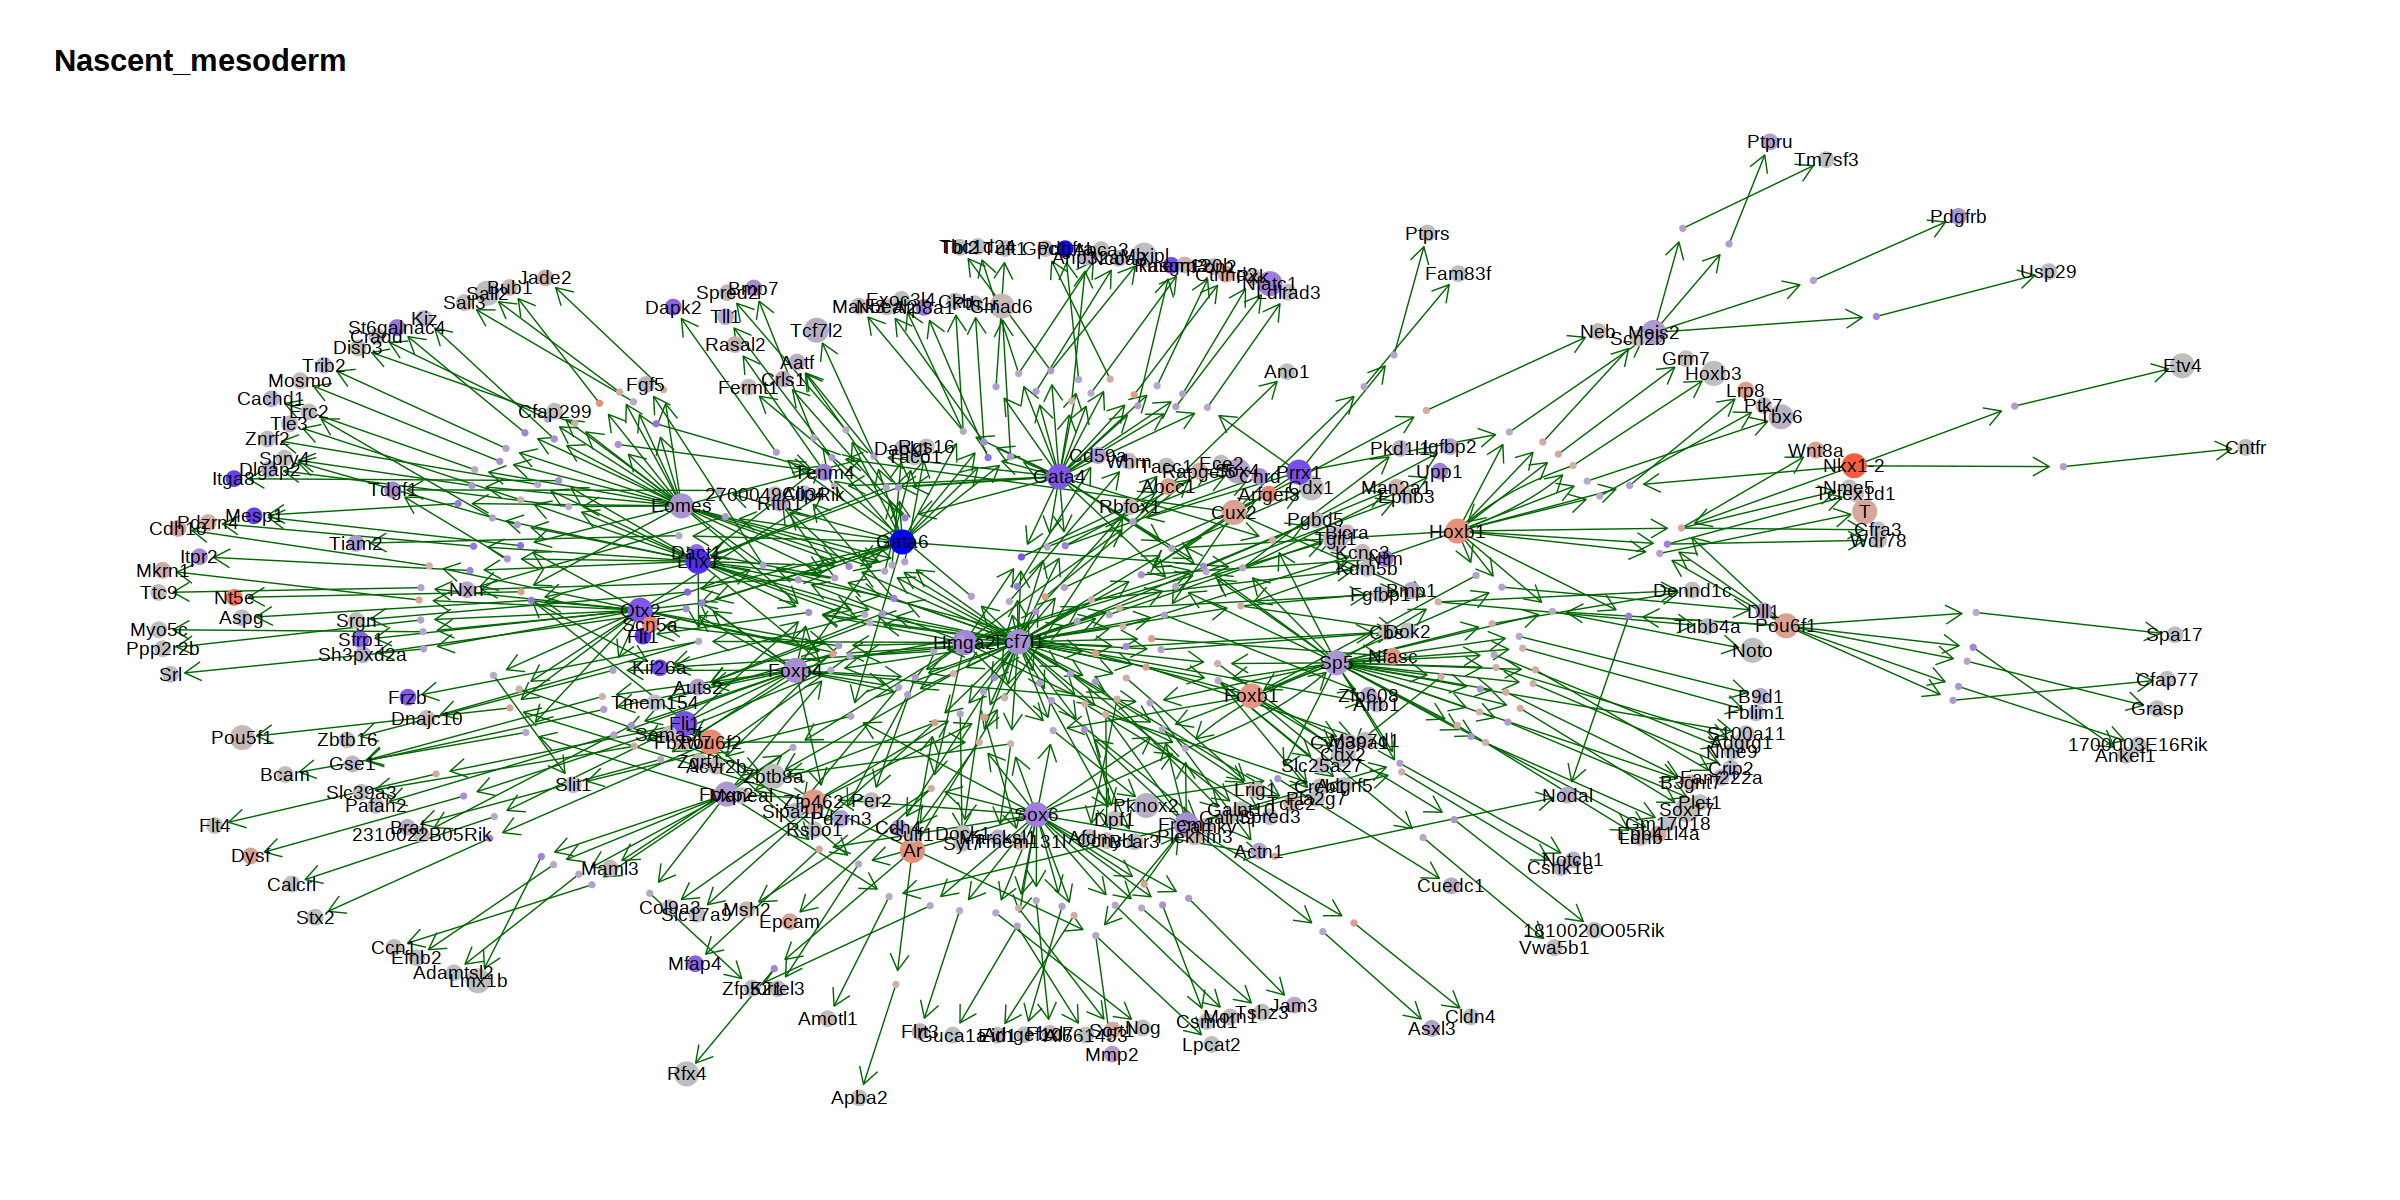

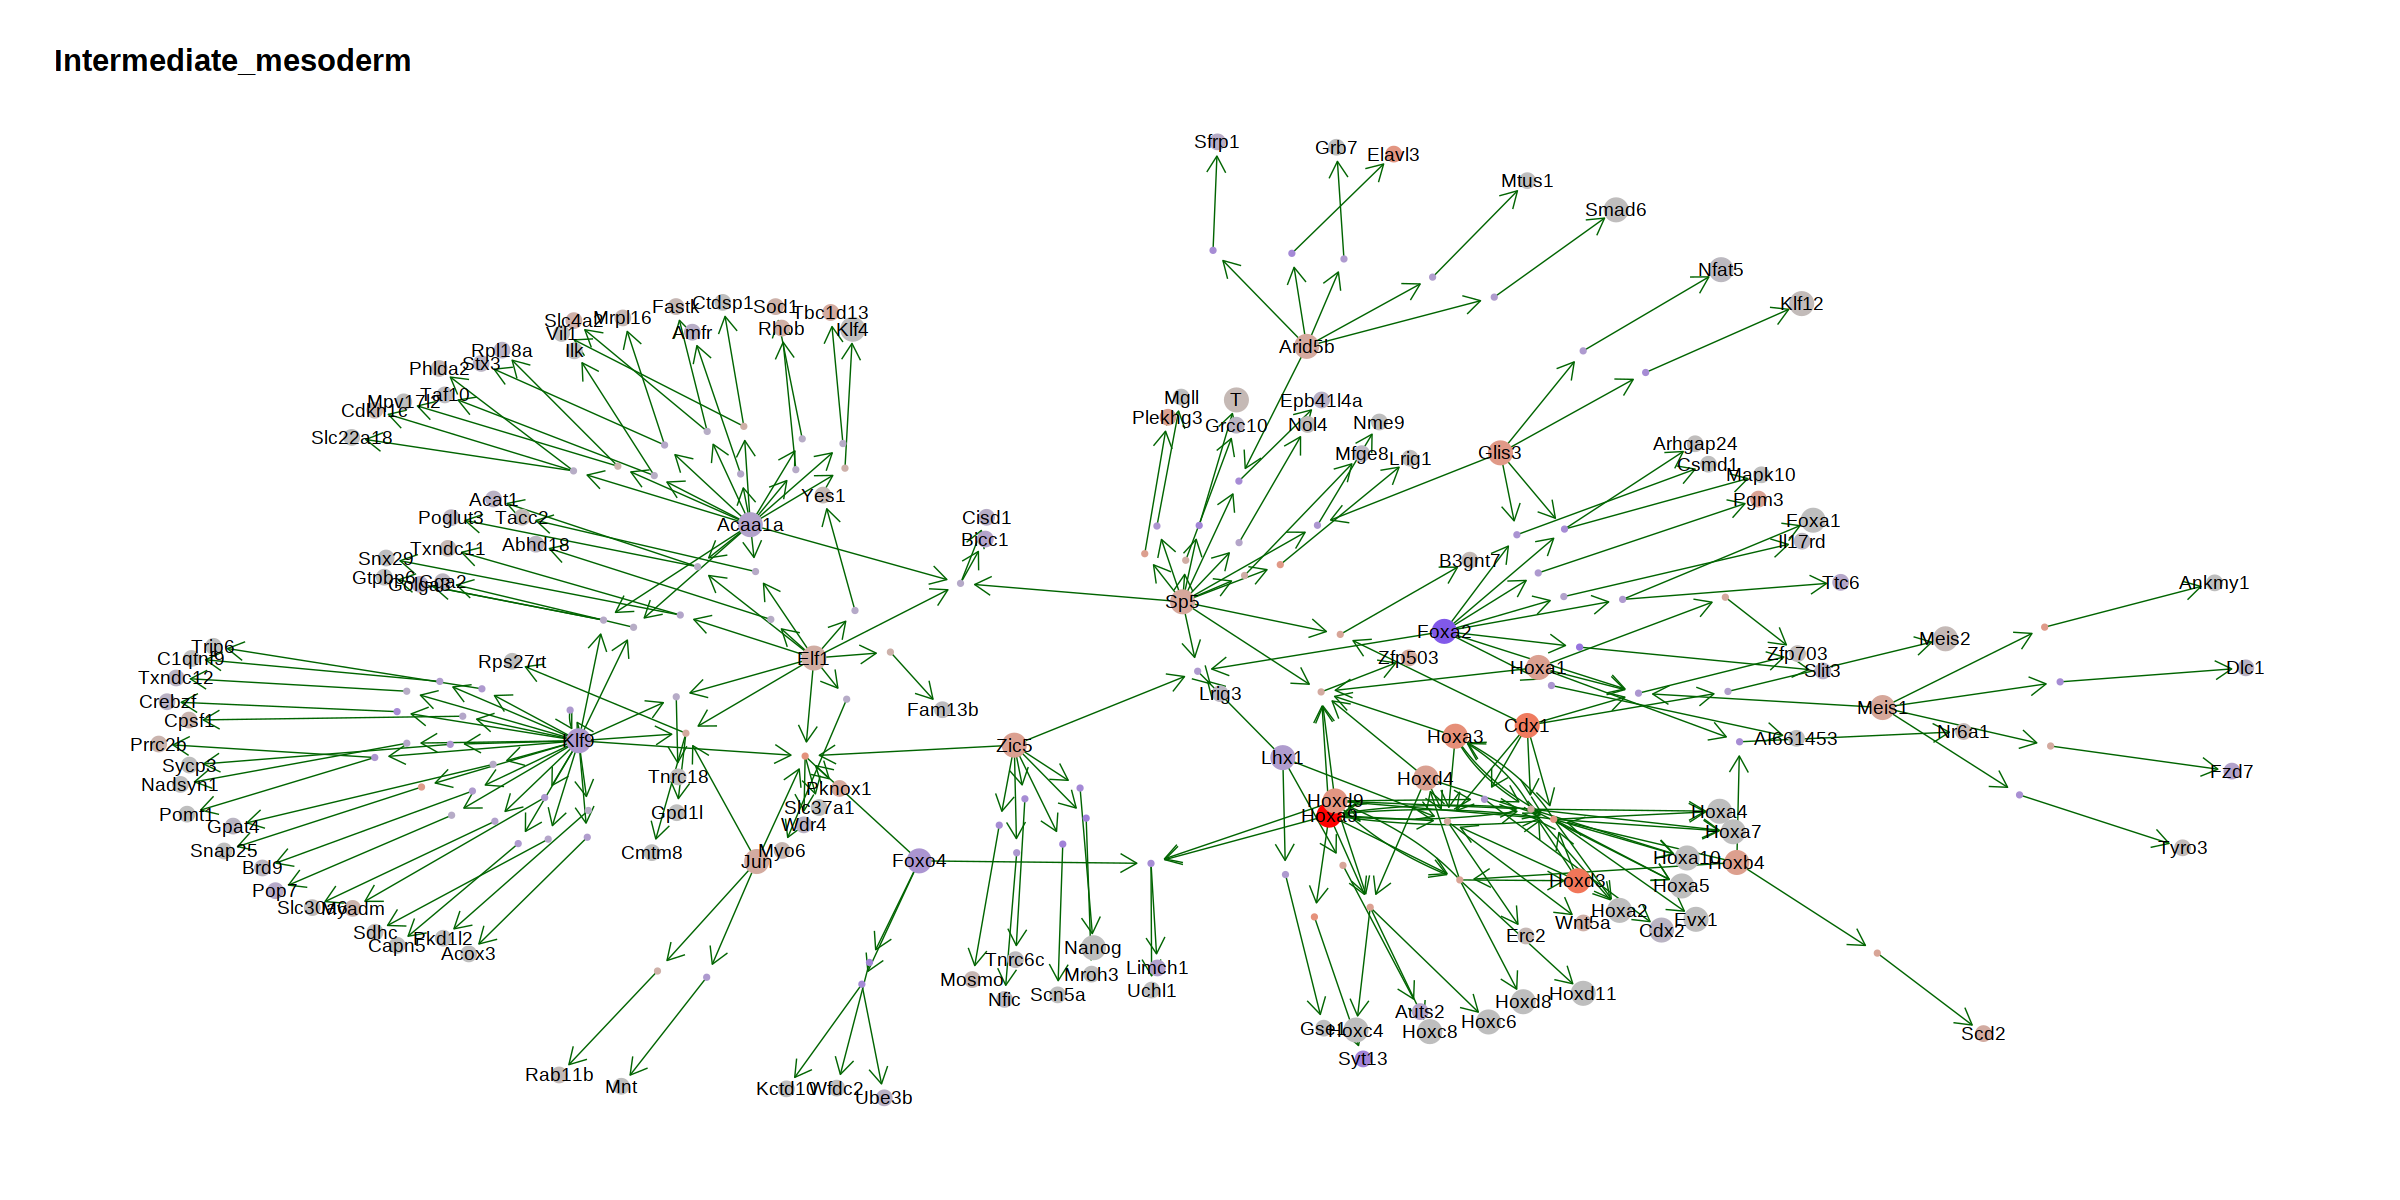

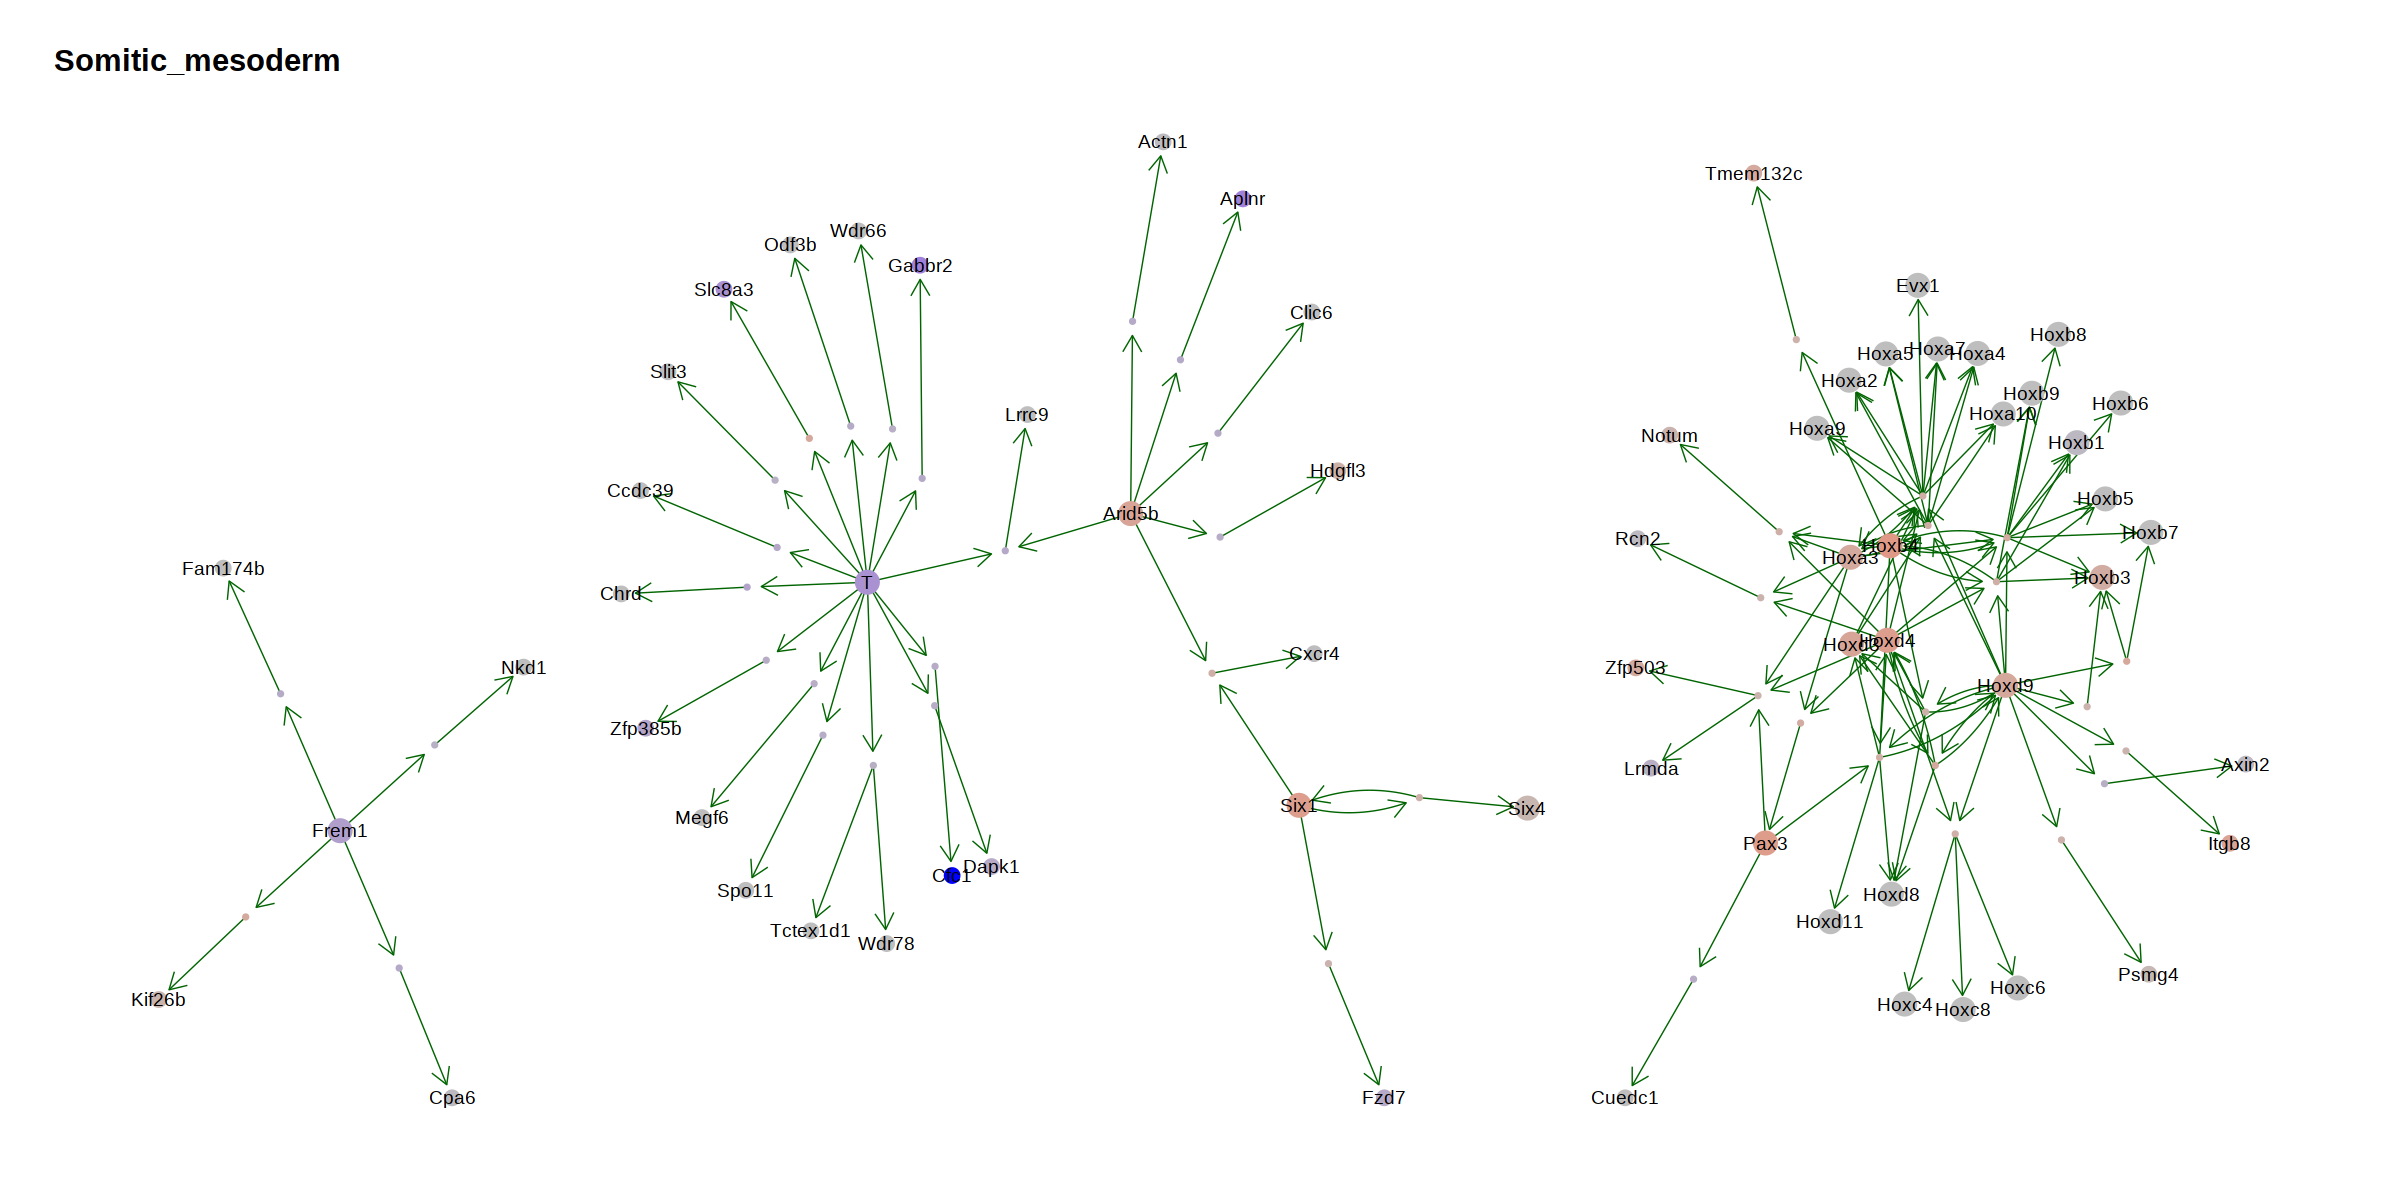

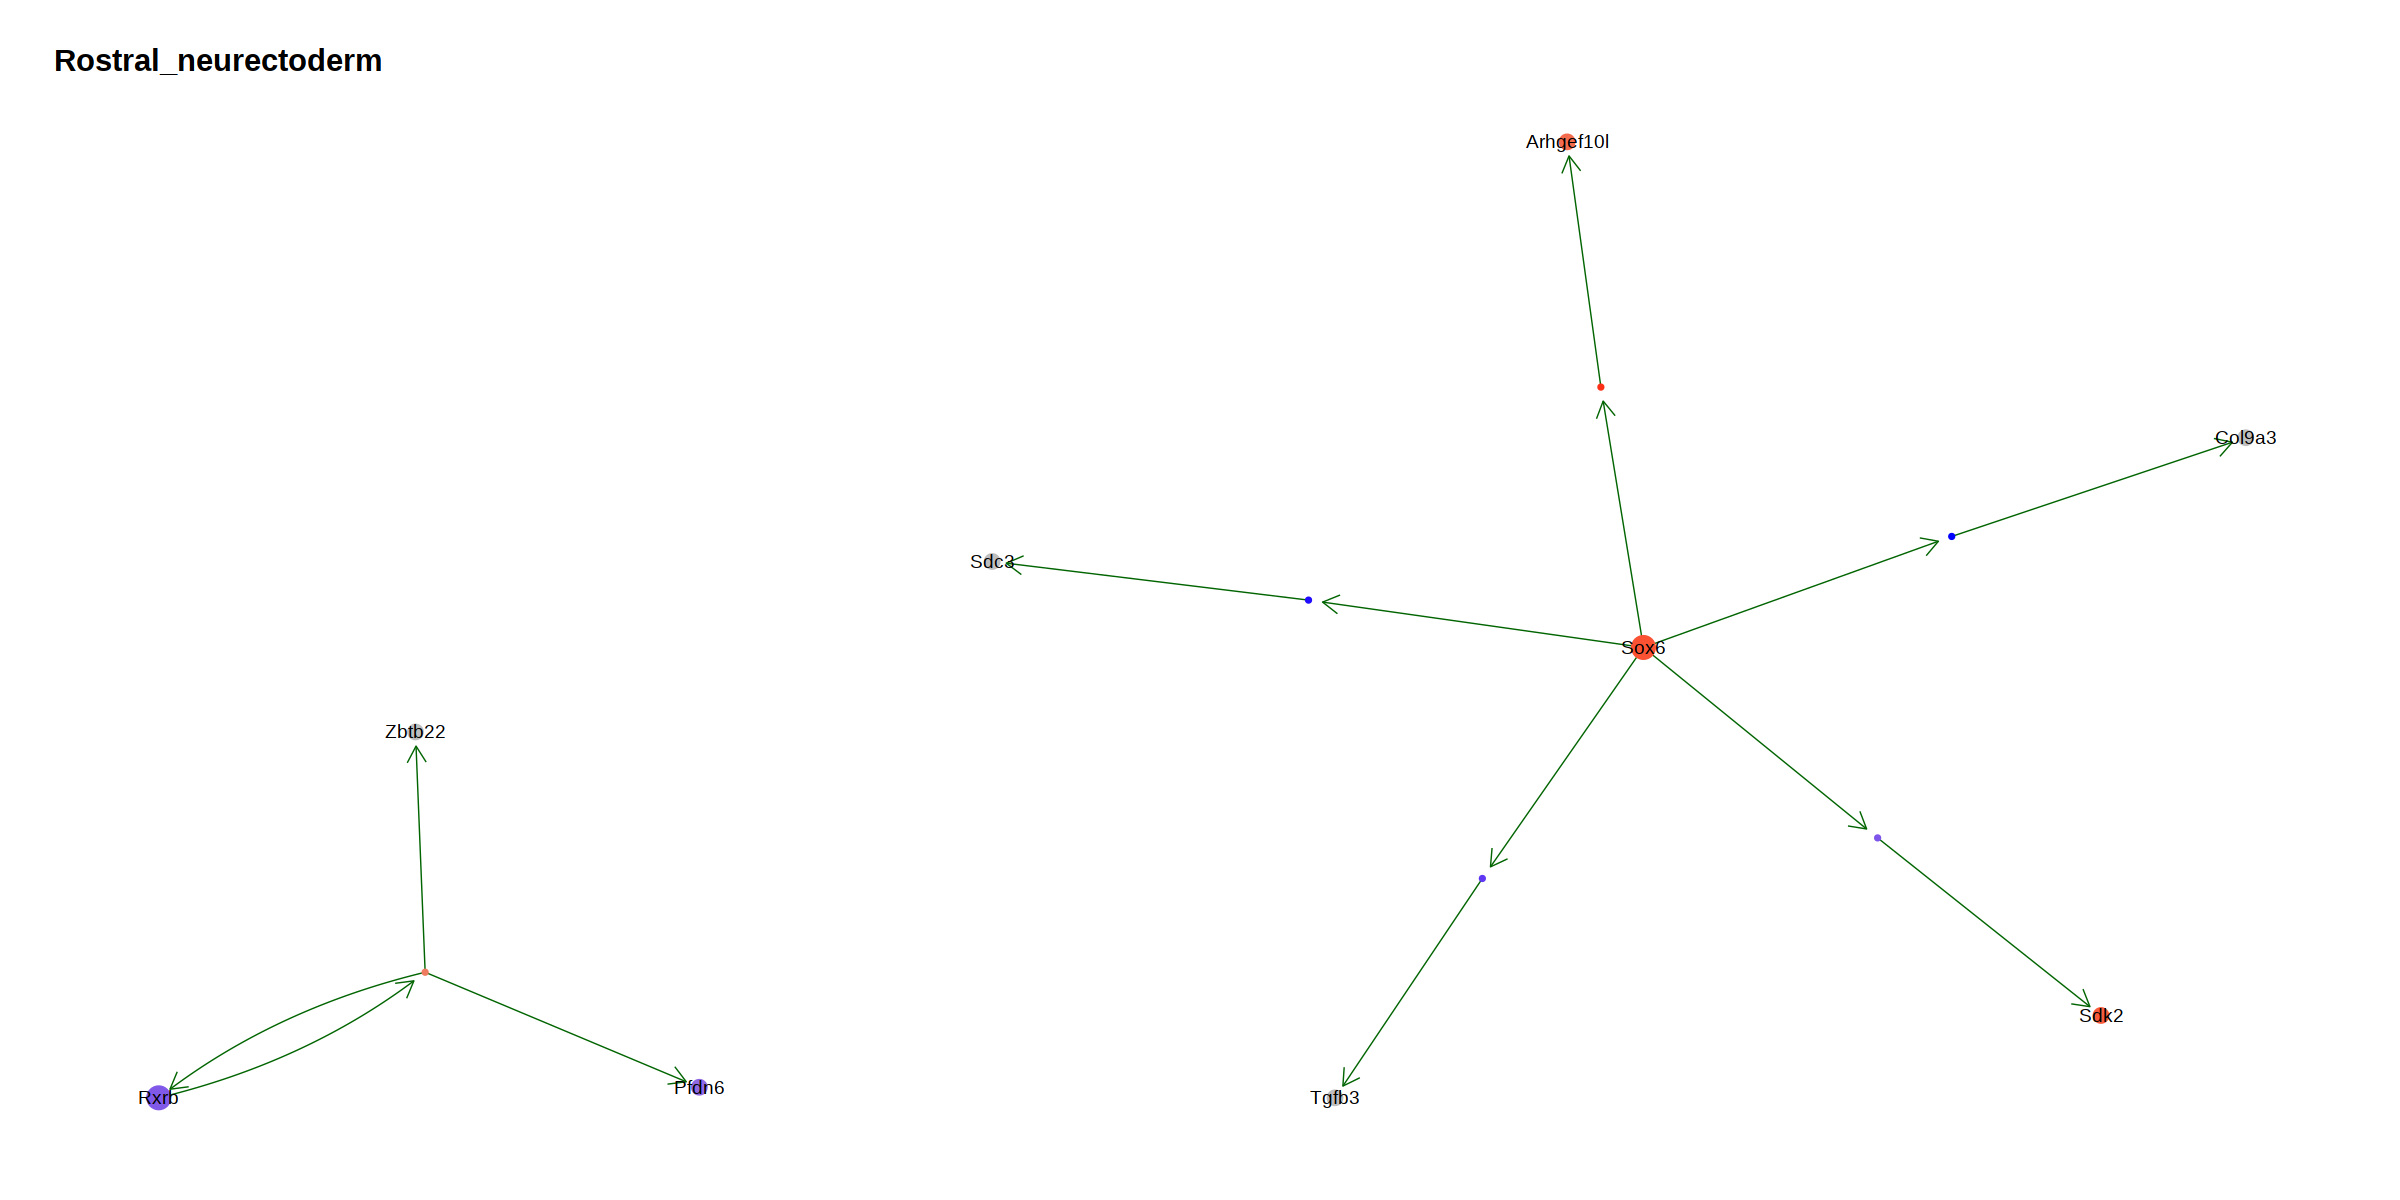

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]


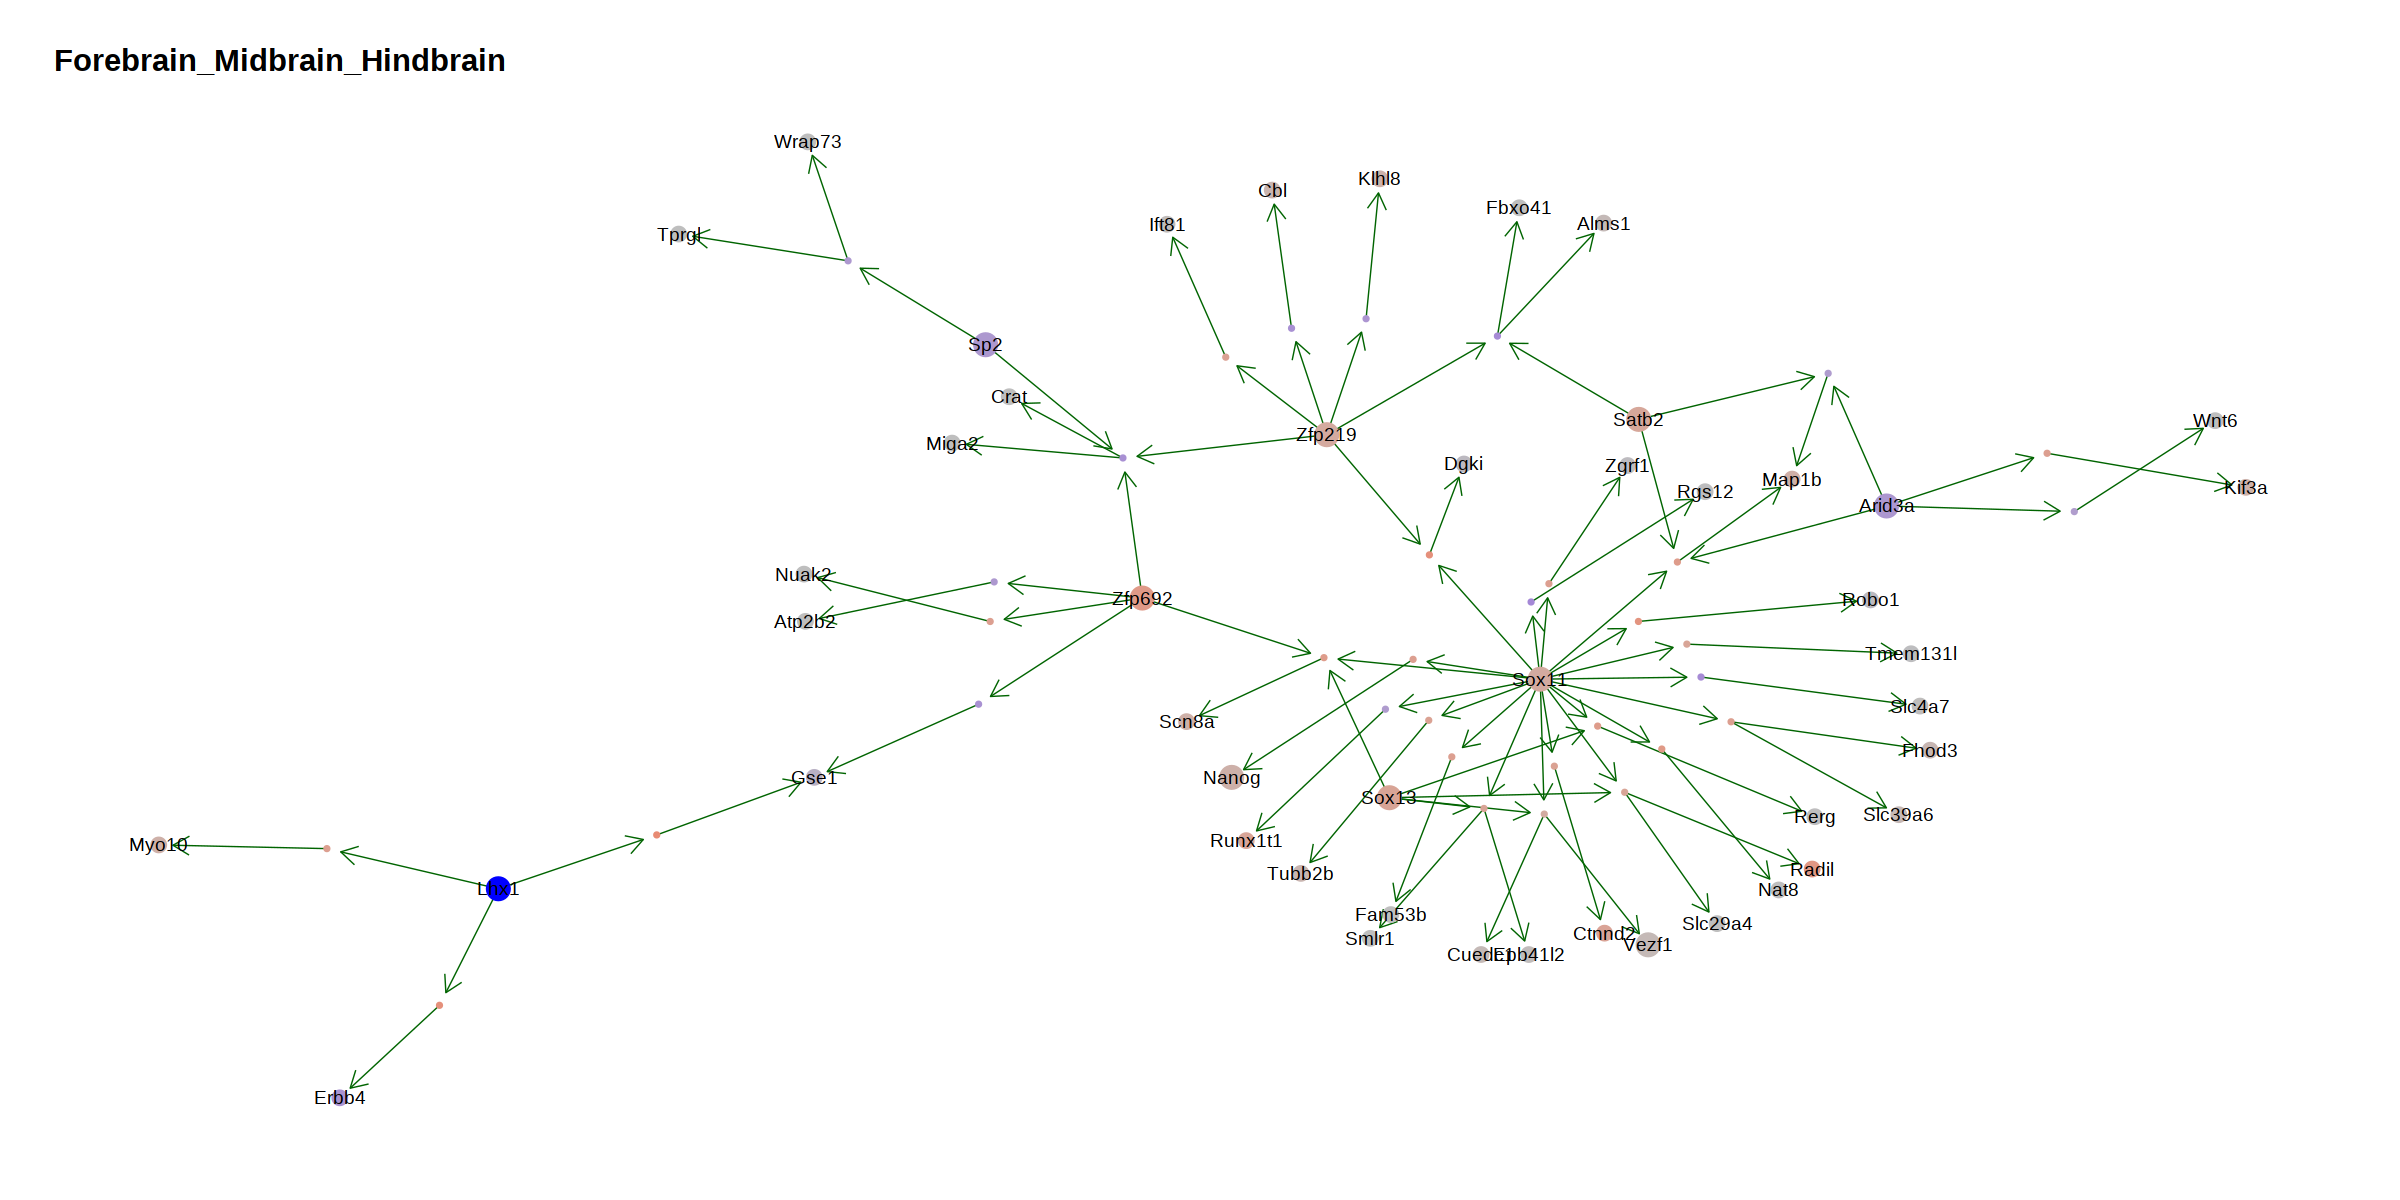

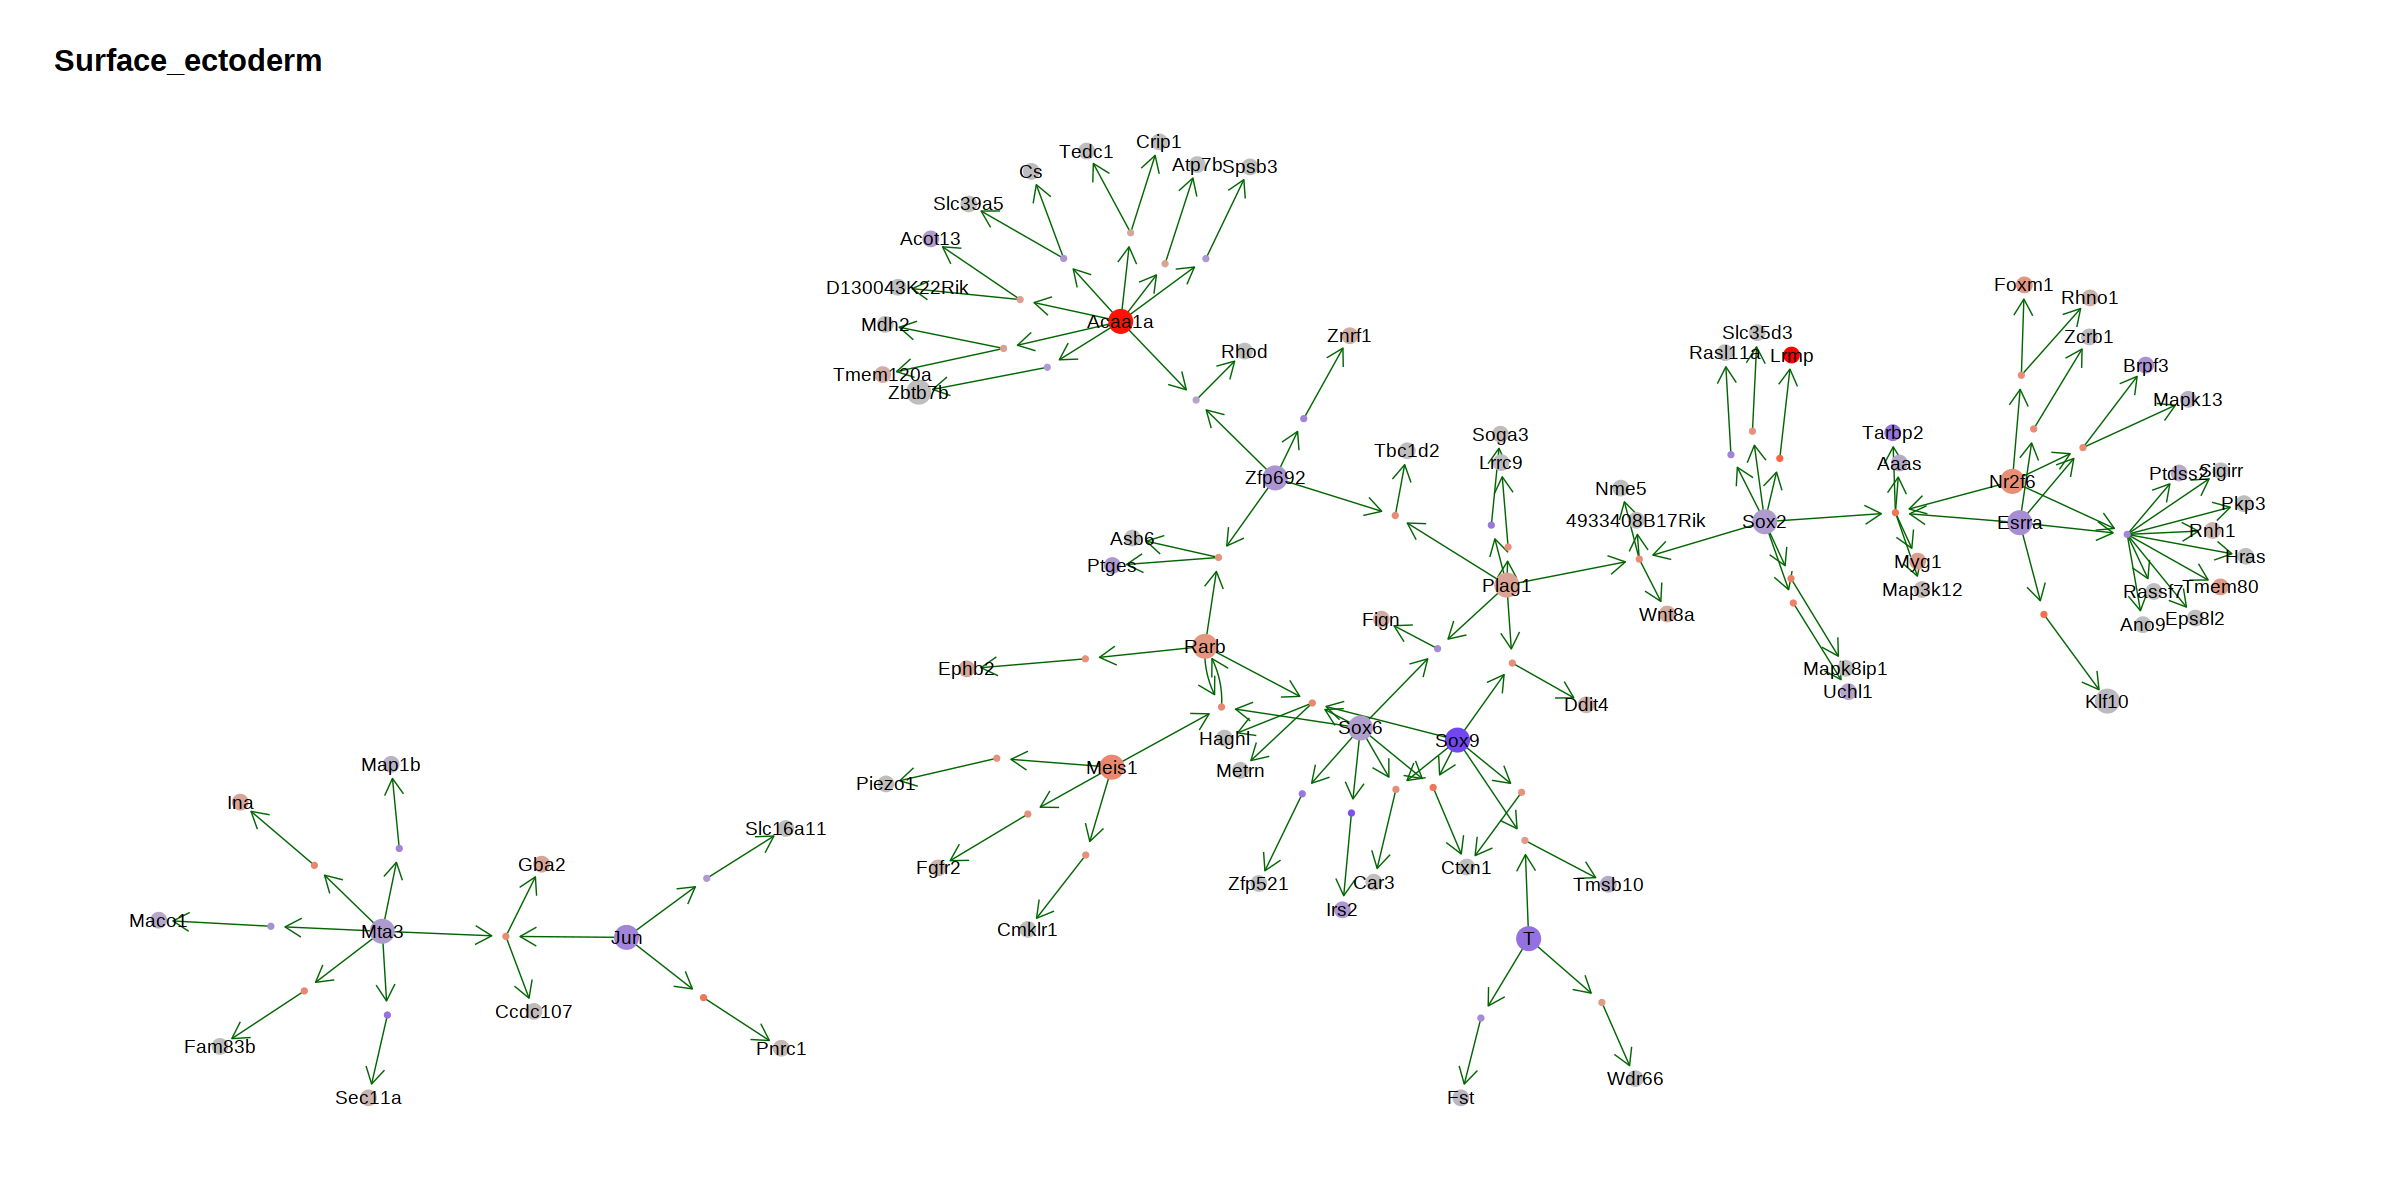

In [33]:
ct_keep = c('Epiblast', 'Primitive_Streak', 'PGC', 'Anterior_Primitive_Streak', 'Nascent_mesoderm', 'Intermediate_mesoderm', 'Somitic_mesoderm', 'Rostral_neurectoderm', 'Forebrain_Midbrain_Hindbrain', 'Surface_ectoderm')
lapply(ct_keep, plotDGRN)

In [37]:
celltype_i = 'Primitive_Streak'

In [104]:
DEGs_tmp[sig==TRUE, gene]

[1] "Adamts9"       "Kcnh8"         "Dscam"         "Sgcd"         
 [5] "Zfpm2"         "Tdrd5"         "Cdh11"         "Cpeb2"        
 [9] "Nav3"          "Dapk2"         "Eml6"          "2610035D17Rik"
[13] "Rnf152"        "Gsc"           "Upp1"          "Samd5"        
[17] "Limch1"        "Dner"          "Pdzd2"         "Crtac1"       
[21] "Pcdh11x"       "Plxna2"        "Mixl1"         "Foxa2"        
[25] "Dusp4"         "Olfr539"       "Nkx1-2"        "Notum"        
[29] "Nefl"          "Ost4"          "Snca"          "Ets1"         
[33] "Rpa3"          "9530026P05Rik" "Bmp7"          "Ntrk3"        
[37] "Ndrg1"         "D030055H07Rik"

In [108]:
celltype_i = 'Anterior_Primitive_Streak'

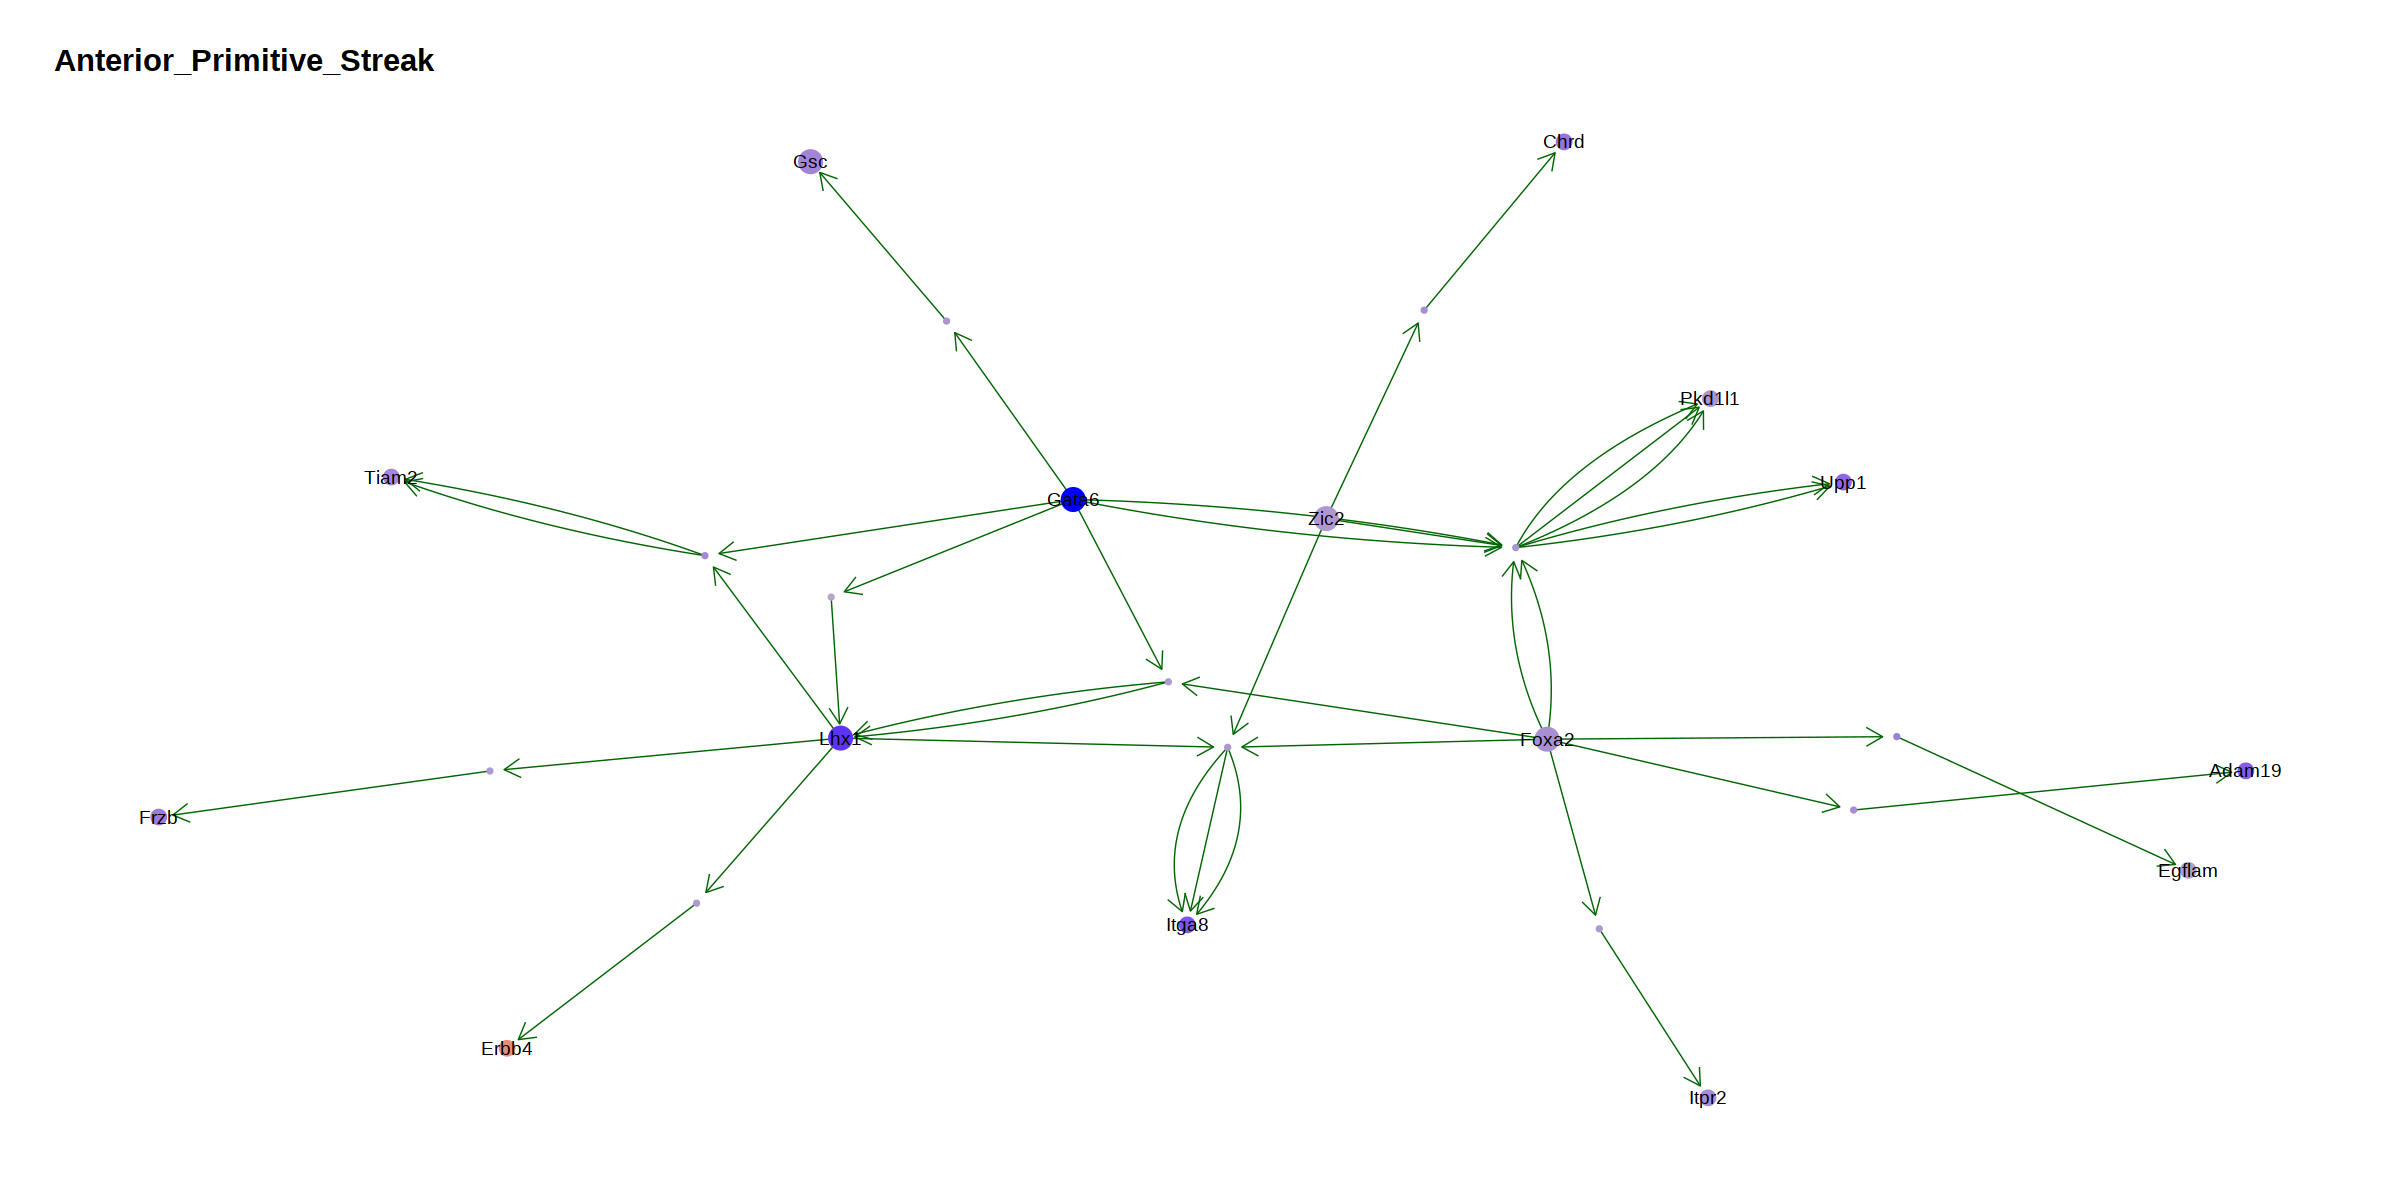

In [134]:
#plotDGRN = function(celltype_i){
    DARs_tmp = DARs[celltype == celltype_i, c('feature', 'logFC', 'sig')]
    DEGs_tmp = DEGs[celltype == celltype_i, c('gene', 'logFC', 'sig')]
    scenic_eGRN_tmp = scenic_eGRN[TF %in% DEGs_tmp[sig==TRUE, gene] & Gene %in% DEGs_tmp[sig==TRUE, gene] |  
                                  Region %in% DARs_tmp[sig==TRUE, feature] & Gene %in% DEGs_tmp[sig==TRUE, gene]] %>%
        .[TF %in% .[,.N,by="TF"][N>=3,TF]] # keep only TFs with 3 or more targets differential
    
    TF_region = scenic_eGRN_tmp[,c('TF', 'Region', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    region_gene = scenic_eGRN_tmp[,c('Region', 'Gene', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    edges = rbind(TF_region, region_gene)
    
    DAR_DEGs = rbind(DARs_tmp, DEGs_tmp, use.names=FALSE) %>% setnames('feature', 'node')
    
    edges_tmp = edges#[node %in% c(DARs_tmp$feature, DEGs_tmp$gene)] %>%
    #unique(by=c('node', 'target'))
    
    
    nodes_tmp = data.table(node = unique(c(edges_tmp$node, edges_tmp$target))) %>%
    .[,type:=ifelse(node %in% scenic_eGRN$TF, 'TF', ifelse(node %in% scenic_eGRN$Region, 'Region', 'gene'))] %>%
    merge(.,DAR_DEGs, by='node', all.x=TRUE) %>%
    .[,logFC:=ifelse(is.na(logFC), 0, logFC)]
    
    igraph.tbl = tbl_graph(edges = edges_tmp, nodes = nodes_tmp)
    
    options(repr.plot.width=20, repr.plot.height=10)

    ggraph(igraph.tbl, 'stress') +
    # Edges
        geom_edge_fan(edge_color = 'darkgreen', edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(3,'mm'), show.legend = T) + 
    # nodes
        geom_node_point(aes(color=logFC, size=ifelse(type=='TF', 10, ifelse(type=='Region', 3, 5)))) + 
        scale_colour_gradient2(low='blue', mid='gray', high='red') +
        geom_node_text(aes(filter=type!='Region', label=node)) +
    ggtitle(celltype_i) + 
    theme_graph() + 
    theme(legend.position='none',
        text=element_text(size=20)) 
        
#}

In [126]:
scenic_eGRN_tmp = scenic_eGRN_tmp[TF=='Pou6f2']

In [130]:
edges

node,target,TF2G_rho
<chr>,<chr>,<dbl>
Pou6f2,chr5:102751542-102752142,0.2492166
Pou6f2,chr1:59394590-59395190,0.1442475
Pou6f2,chr1:59449380-59449980,0.1442475
Pou6f2,chr1:59590539-59591139,0.1442475
Pou6f2,chr1:59340809-59341409,0.1442475
Pou6f2,chr13:18218569-18219169,1.0000000
Pou6f2,chr13:18457486-18458086,1.0000000
Pou6f2,chr13:18495379-18495979,1.0000000
Pou6f2,chr13:18281007-18281607,1.0000000


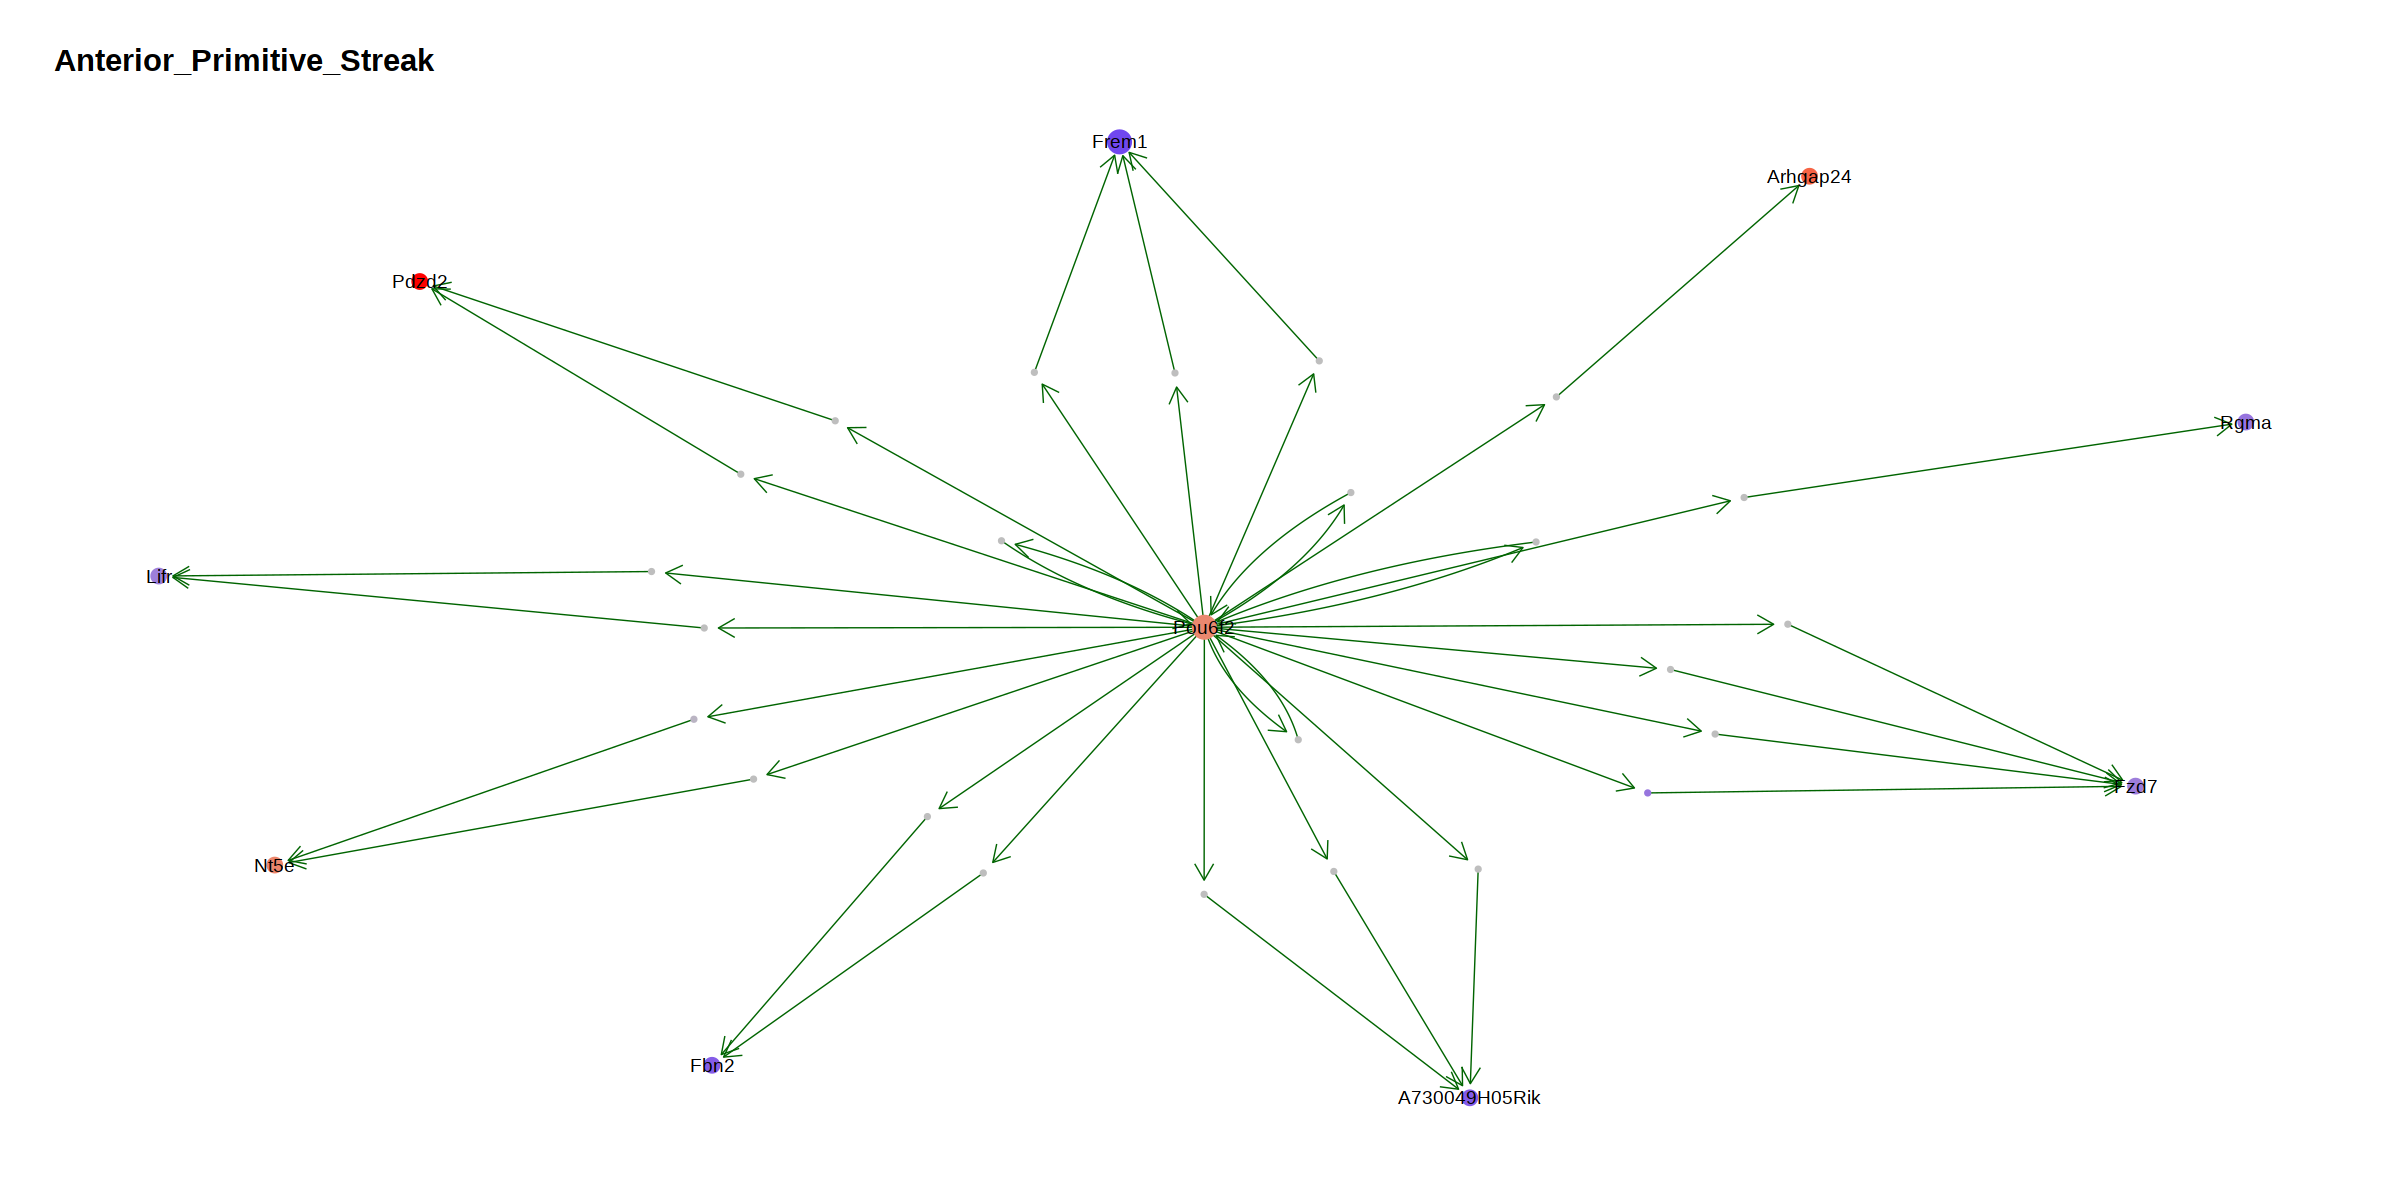

In [132]:
    TF_region = scenic_eGRN_tmp[,c('TF', 'Region', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    region_gene = scenic_eGRN_tmp[,c('Region', 'Gene', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    edges = rbind(TF_region, region_gene)
    
    DAR_DEGs = rbind(DARs_tmp, DEGs_tmp, use.names=FALSE) %>% setnames('feature', 'node')
    
    edges_tmp = edges#[node %in% c(DARs_tmp$feature, DEGs_tmp$gene)] %>%
        #unique(by=c('node', 'target'))
    
    
    nodes_tmp = data.table(node = unique(c(edges_tmp$node, edges_tmp$target))) %>%
    .[,type:=ifelse(node %in% scenic_eGRN$TF, 'TF', ifelse(node %in% scenic_eGRN$Region, 'Region', 'gene'))] %>%
    merge(.,DAR_DEGs, by='node', all.x=TRUE) %>%
    .[,logFC:=ifelse(is.na(logFC), 0, logFC)]
    
    igraph.tbl = tbl_graph(edges = edges_tmp, nodes = nodes_tmp)
    
    options(repr.plot.width=20, repr.plot.height=10)

    ggraph(igraph.tbl, 'stress') +
    # Edges
        geom_edge_fan(edge_color = 'darkgreen', edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(3,'mm'), show.legend = T) + 
    # nodes
        geom_node_point(aes(color=logFC, size=ifelse(type=='TF', 10, ifelse(type=='Region', 3, 5)))) + 
        scale_colour_gradient2(low='blue', mid='gray', high='red') +
        geom_node_text(aes(filter=type!='Region', label=node)) +
    ggtitle(celltype_i) + 
    theme_graph() + 
    theme(legend.position='none',
        text=element_text(size=20)) 

In [145]:
plot_dGRN_TF = function(TF_i, celltype_i, depth){
    DARs_tmp = DARs[celltype == celltype_i, c('feature', 'logFC', 'sig')]
    DEGs_tmp = DEGs[celltype == celltype_i, c('gene', 'logFC', 'sig')]
    scenic_eGRN_tmp = scenic_eGRN[TF %in% DEGs_tmp[sig==TRUE, gene] & Gene %in% DEGs_tmp[sig==TRUE, gene] |  
                                  Region %in% DARs_tmp[sig==TRUE, feature] & TF %in% DEGs_tmp[sig==TRUE, gene]] %>%
        .[TF %in% .[,.N,by="TF"][N>=3,TF]] # keep only TFs with 3 or more targets differential
    
    scenic_eGRN_tmp = scenic_eGRN_tmp[TF %in% TF_i]
    
    TF_region = scenic_eGRN_tmp[,c('TF', 'Region', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    region_gene = scenic_eGRN_tmp[,c('Region', 'Gene', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    edges = rbind(TF_region, region_gene)
    
    DAR_DEGs = rbind(DARs_tmp, DEGs_tmp, use.names=FALSE) %>% setnames('feature', 'node')
    
    edges_tmp = edges %>% #[node %in% c(DARs_tmp$feature, DEGs_tmp$gene)] %>%
     unique(by=c('node', 'target'))
    
    
    nodes_tmp = data.table(node = unique(c(edges_tmp$node, edges_tmp$target))) %>%
    .[,type:=ifelse(node %in% scenic_eGRN$TF, 'TF', ifelse(node %in% scenic_eGRN$Region, 'Region', 'gene'))] %>%
    merge(.,DAR_DEGs, by='node', all.x=TRUE) %>%
    .[,logFC:=ifelse(is.na(logFC), 0, logFC)]
    
    igraph.tbl = tbl_graph(edges = edges_tmp, nodes = nodes_tmp)
    
    options(repr.plot.width=20, repr.plot.height=10)

    ggraph(igraph.tbl, 'stress') +
    # Edges
        geom_edge_fan(edge_color = 'darkgreen', edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(3,'mm'), show.legend = T) + 
    # nodes
        geom_node_point(aes(color=logFC, size=ifelse(type=='TF', 10, ifelse(type=='Region', 3, 5)))) + 
        scale_colour_gradient2(low='blue', mid='gray', high='red') +
        geom_node_text(aes(filter=type!='Region', label=node)) +
    ggtitle(celltype_i) + 
    theme_graph() + 
    theme(legend.position='none',
        text=element_text(size=20)) 
        
}

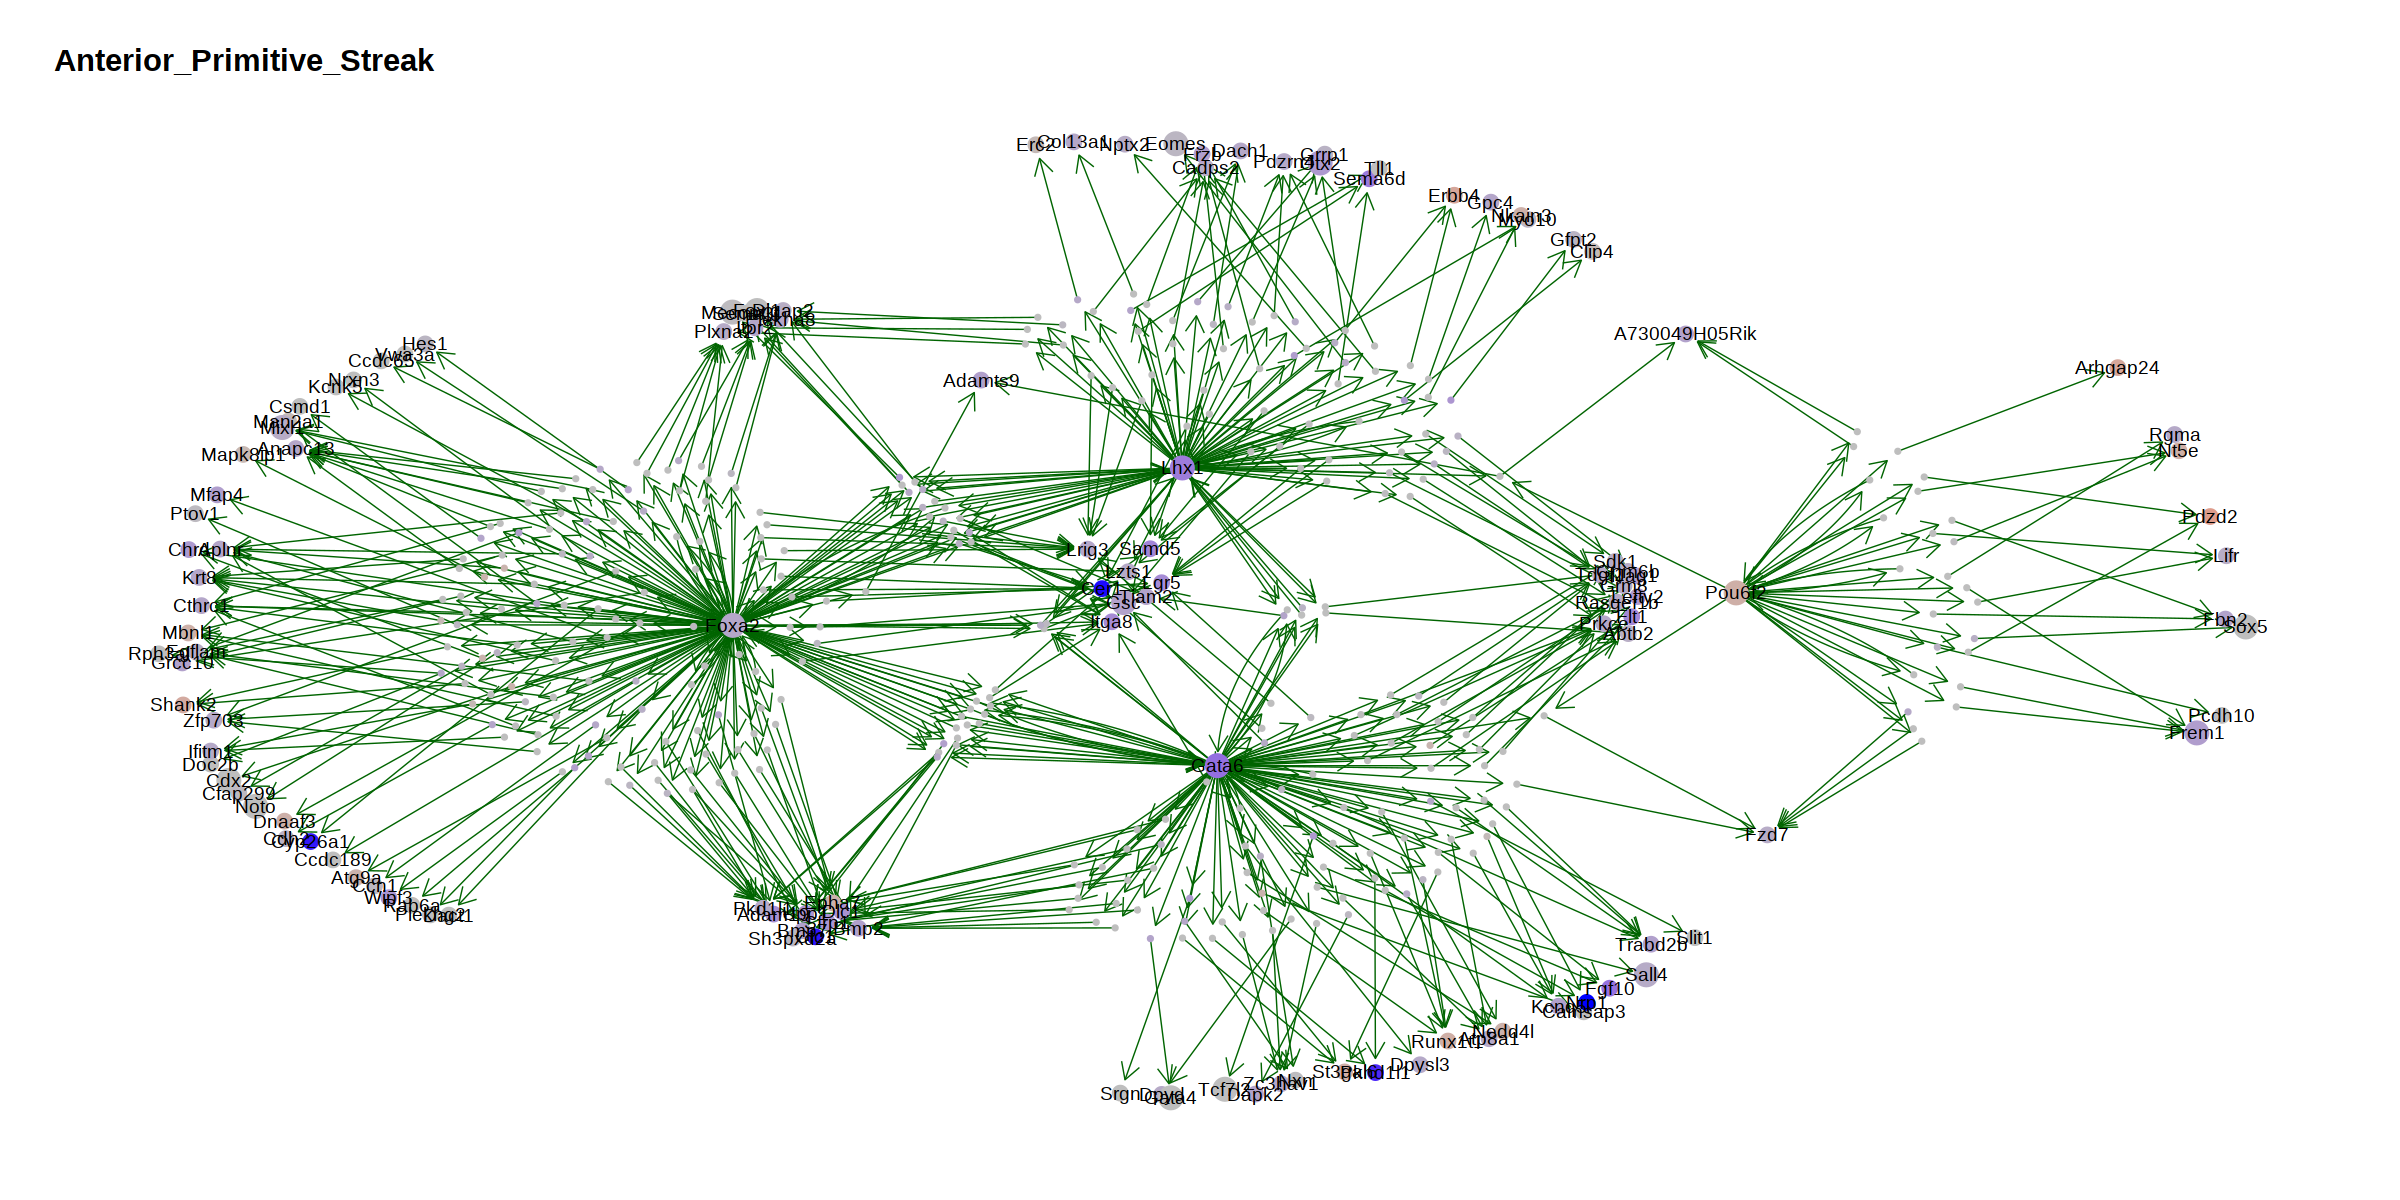

In [146]:
plot_dGRN_TF(TF_i = c('Foxa2', 'Pou6f2', 'Gata6', 'Lhx1'), celltype_i='Anterior_Primitive_Streak')

In [56]:
TF_i='Eomes'
celltype_i= 'Primitive_Streak'
depth=1

In [63]:
    DARs_tmp = DARs[celltype == celltype_i, c('feature', 'logFC', 'sig')]
    DEGs_tmp = DEGs[celltype == celltype_i, c('gene', 'logFC', 'sig')]
    scenic_eGRN_tmp = scenic_eGRN[TF %in% DEGs_tmp[sig==TRUE, gene] | Region %in% DARs_tmp[sig==TRUE, feature]] 
    
    scenic_eGRN_TF = scenic_eGRN_tmp[Gene==TF_i | TF==TF_i]    

In [64]:
head(scenic_eGRN_TF)

V1,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>
172,Eomes_+_(320r),Eomes_+_(206g),Eomes,FALSE,chr9:16361688-16362288,Fat3,0.04478174,0.55156259,0.0246999303,0.0246999303,18.176239,1,0.4430720,8.0533820,8.0533820,Eomes_+_+
207,Eomes_+_(320r),Eomes_+_(206g),Eomes,FALSE,chr12:71301531-71302131,Dact1,0.06456463,0.14894952,0.0096168710,0.0096168710,19.427138,1,0.2689429,5.2247905,5.2247905,Eomes_+_+
215,Eomes_+_(320r),Eomes_+_(206g),Eomes,FALSE,chr4:55208827-55209427,Zfp462,0.04028604,0.20408024,0.0082215840,0.0082215840,1.945078,1,0.2519716,0.4901045,0.4901045,Eomes_+_+
264,Eomes_+_(320r),Eomes_+_(206g),Eomes,FALSE,chr13:60621421-60622021,Dapk1,0.07903149,0.34965769,0.0276339672,0.0276339672,53.230783,1,0.5256046,27.9783418,27.9783418,Eomes_+_+
293,Eomes_+_(320r),Eomes_+_(206g),Eomes,FALSE,chr7:120767021-120767621,Mosmo,0.01432561,0.06655538,0.0009534465,0.0009534465,1.743199,1,0.3023537,0.5270628,0.5270628,Eomes_+_+


In [74]:
scenic_eGRN_TF2 = cbind(scenic_eGRN_TF, scenic_eGRN_tmp[TF %in% Gene])

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 1 has 5 rows but longest item has 1514; recycled with remainder.”


In [80]:
nrow(scenic_eGRN_TF2)

[1] 1514

In [81]:
scenic_eGRN_TF = scenic_eGRN_TF2

In [82]:
    
    TF_region = scenic_eGRN_TF[,c('TF', 'Region', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    region_gene = scenic_eGRN_TF[,c('Region', 'Gene', 'TF2G_rho')] %>% setnames(c('node', 'target', 'TF2G_rho'))
    edges = rbind(TF_region, region_gene)
    
    DAR_DEGs = rbind(DARs_tmp, DEGs_tmp, use.names=FALSE) %>% setnames('feature', 'node')
    
    edges_tmp = edges[node %in% c(DARs_tmp$feature, DEGs_tmp$gene)] %>%
        unique(by=c('node', 'target'))

In [83]:
head(scenic_eGRN_tmp)
head(edges_tmp)
nrow(edges_tmp)

V1,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>
180,Bach1_+_(380r),Bach1_+_(393g),Bach1,FALSE,chr11:107545990-107546590,Helz,0.01539562,0.3595128,0.005534924,0.005534924,0.2635537,1,0.43145205,0.11371076,0.11371076,Bach1_+_+
462,Bach1_+_(380r),Bach1_+_(393g),Bach1,FALSE,chr11:107545990-107546590,Psmd12,0.05466589,0.2180315,0.011918886,0.011918886,0.3489430,1,0.38489522,0.13430649,0.13430649,Bach1_+_+
6,Bach2_+_(102r),Bach2_+_(95g),Bach2,FALSE,chr15:102017761-102018361,Krt8,0.06448829,0.4590327,0.029602238,0.029602238,0.5173674,1,0.08857791,0.04582732,0.04582732,Bach2_+_+
308,Cdx1_+_(382r),Cdx1_+_(146g),Cdx1,FALSE,chr11:76476874-76477474,Nxn,0.05406301,0.1389249,0.007510700,0.007510700,6.4379634,1,0.17868840,1.15038941,1.15038941,Cdx1_+_+
432,Cdx1_+_(382r),Cdx1_+_(146g),Cdx1,FALSE,chr9:45117826-45118426,Scn2b,0.03738555,0.1128024,0.004217180,0.004217180,7.5087017,1,0.14764464,1.10861958,1.10861958,Cdx1_+_+
560,Cdx2_+_(878r),Cdx2_+_(389g),Cdx2,FALSE,chr12:118811436-118812036,Sp8,0.02813698,0.1831537,0.005153393,0.005153393,1.5323040,1,0.19000772,0.29114959,0.29114959,Cdx2_+_+


node,target,TF2G_rho
<chr>,<chr>,<dbl>
Eomes,chr9:16361688-16362288,0.4430720
Eomes,chr12:71301531-71302131,0.2689429
Eomes,chr4:55208827-55209427,0.2519716
Eomes,chr13:60621421-60622021,0.5256046
Eomes,chr7:120767021-120767621,0.3023537
chr9:16361688-16362288,Fat3,0.4430720


[1] 10

In [78]:
    nodes_tmp = data.table(node = unique(c(edges_tmp$node, edges_tmp$target))) %>%
    .[,type:=ifelse(node %in% scenic_eGRN$TF, 'TF', ifelse(node %in% scenic_eGRN$Region, 'Region', 'gene'))] %>%
    merge(.,DAR_DEGs, by='node', all.x=TRUE) %>%
    .[,logFC:=ifelse(is.na(logFC), 0, logFC)]

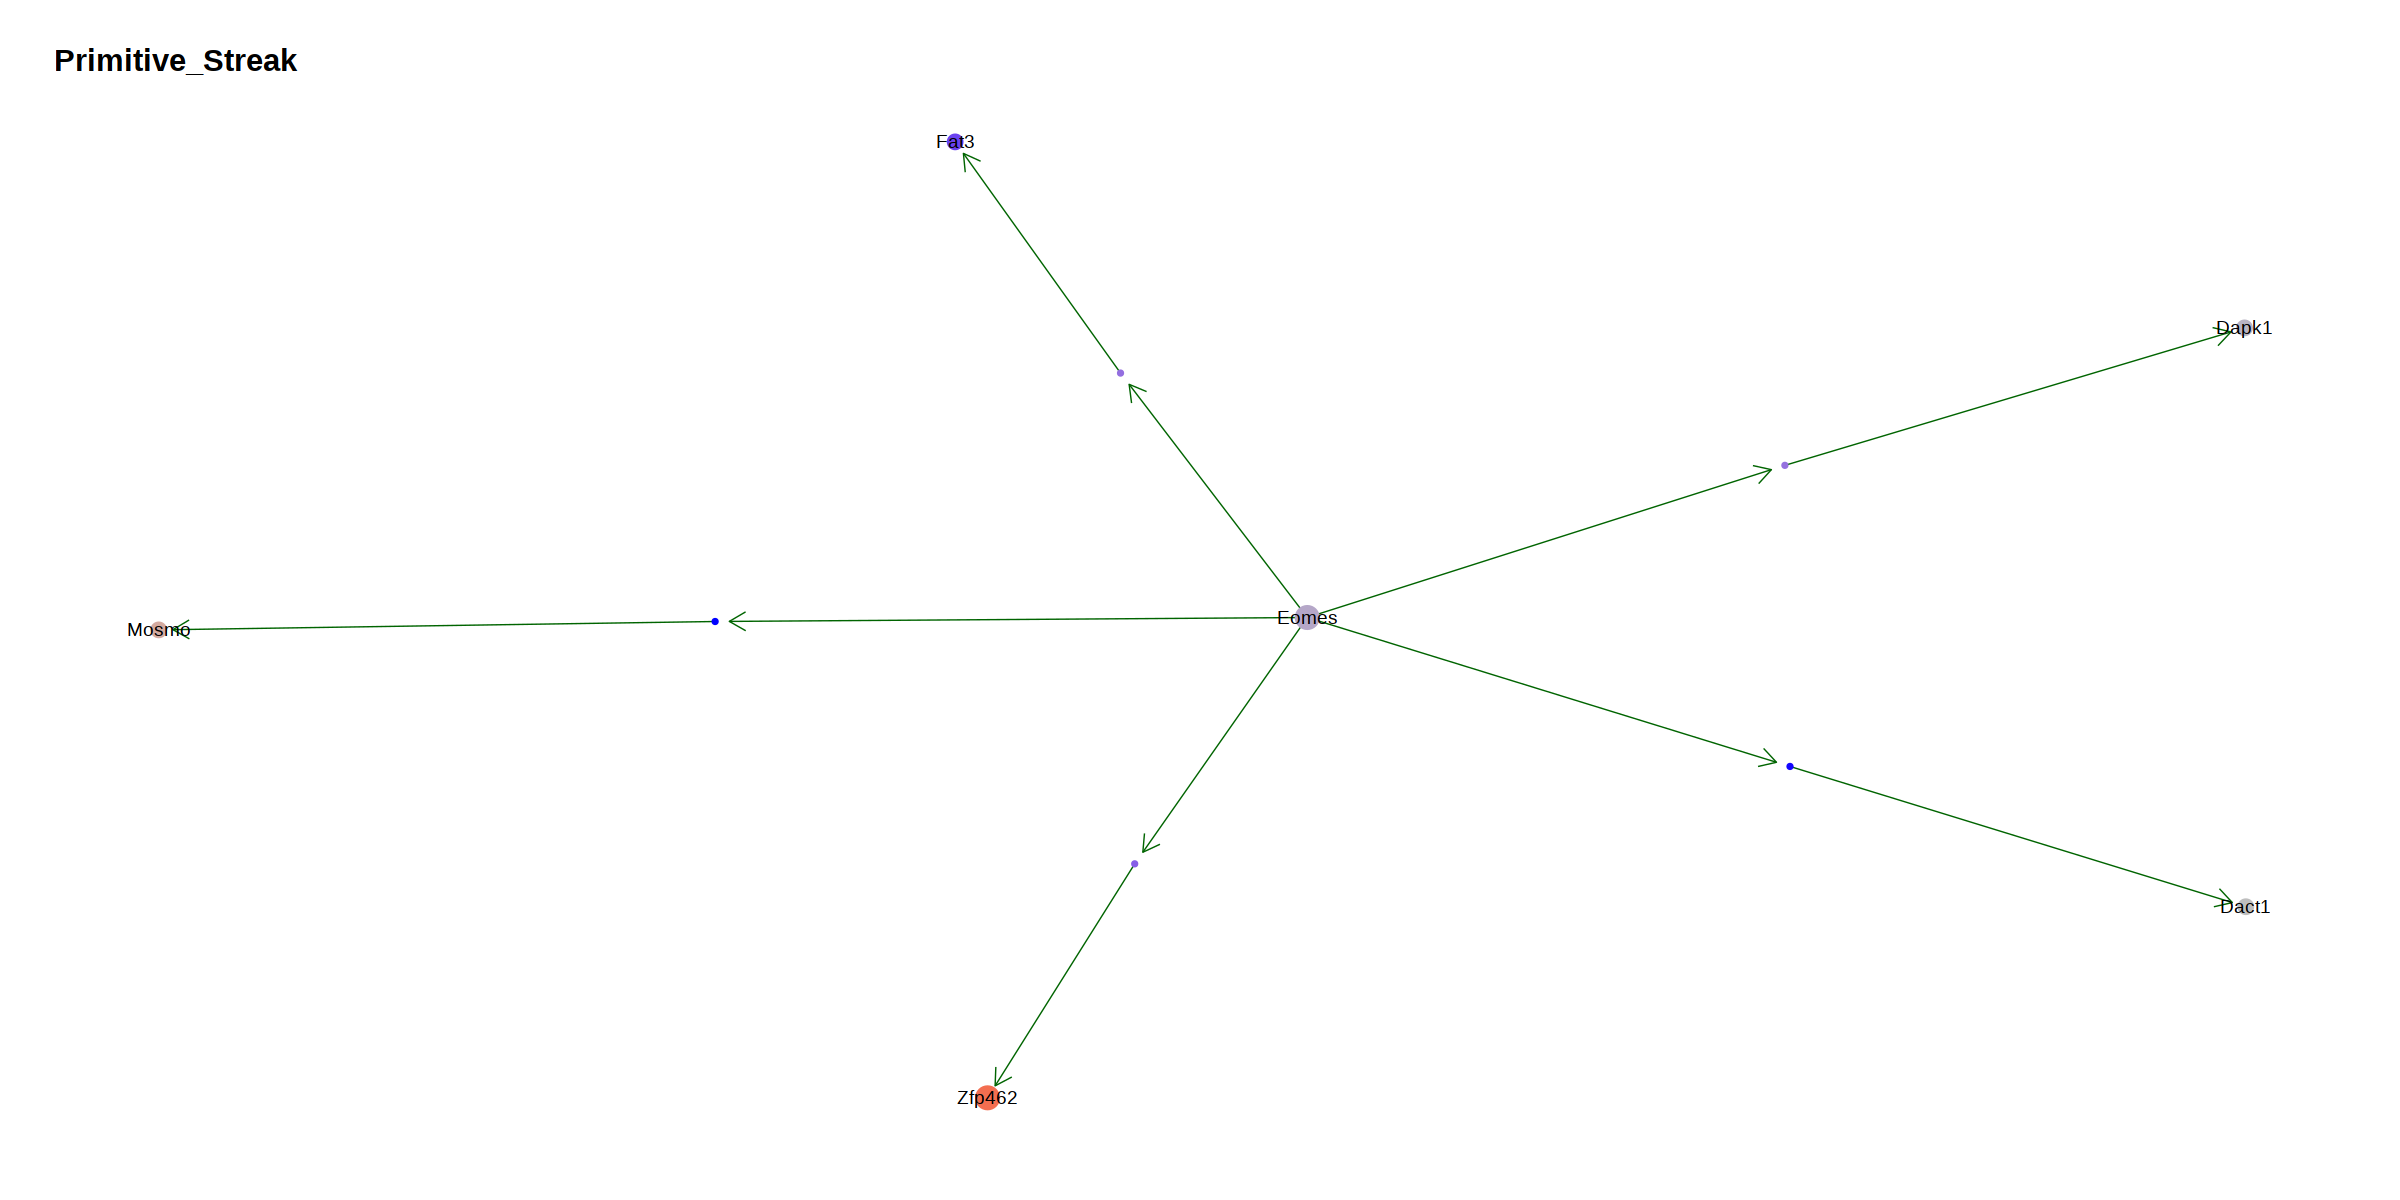

In [79]:
    igraph.tbl = tbl_graph(edges = edges_tmp, nodes = nodes_tmp)
    
    options(repr.plot.width=20, repr.plot.height=10)

    ggraph(igraph.tbl, 'stress') +
    # Edges
        geom_edge_fan(edge_color = 'darkgreen', edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(3,'mm'), show.legend = T) + 
    # nodes
        geom_node_point(aes(color=logFC, size=ifelse(type=='TF', 10, ifelse(type=='Region', 3, 5)))) + 
        scale_colour_gradient2(low='blue', mid='gray', high='red') +
        geom_node_text(aes(filter=type!='Region', label=node)) +
    ggtitle(celltype_i) + 
    theme_graph() + 
    theme(legend.position='none',
        text=element_text(size=20)) 

In [ ]:
ct_keep = c( 'Primitive_Streak', 'Nascent_mesoderm', 'Mixed_mesoderm', 'ExE_mesoderm', 'Haematoendothelial_progenitors',  'Allantois','Endothelium','Intermediate_mesoderm',  'Mesenchyme')
